# import neddeed columns

In [213]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,mean_absolute_error,confusion_matrix,mean_squared_error,classification_report,silhouette_score
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler,LabelEncoder

from sklearn.linear_model import LinearRegression,SGDRegressor,Lasso,Ridge
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor,BaggingRegressor,ExtraTreesRegressor,VotingRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,BaggingClassifier,ExtraTreesClassifier,VotingClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.cluster import KMeans,DBSCAN

from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import  Dense,Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau,CSVLogger,ModelCheckpoint


# DATA REPRESENTATION

In [214]:
df=pd.read_csv('D:\\PROJECTS\\PROJECT 11\\cities_r2.csv')
df

,name_of_city,state_code,state_name,dist_code,population_total,population_male,population_female,0-6_population_total,0-6_population_male,0-6_population_female,...,literates_female,sex_ratio,child_sex_ratio,effective_literacy_rate_total,effective_literacy_rate_male,effective_literacy_rate_female,location,total_graduates,male_graduates,female_graduates
0,Abohar,3,PUNJAB,9,145238,76840,68398,15870,8587,7283,...,44972,890,848,79.86,85.49,73.59,"30.1452928,74.1993043",16287,8612,7675
1,Achalpur,27,MAHARASHTRA,7,112293,58256,54037,11810,6186,5624,...,43086,928,909,91.99,94.77,89.00,"21.257584,77.5086754",8863,5269,3594
2,Adilabad,28,ANDHRA PRADESH,1,117388,59232,58156,13103,6731,6372,...,37660,982,947,80.51,88.18,72.73,"19.0809075,79.560344",10565,6797,3768
3,Adityapur,20,JHARKHAND,24,173988,91495,82493,23042,12063,10979,...,54515,902,910,83.46,89.98,76.23,"22.7834741,86.1576889",19225,12189,7036
4,Adoni,28,ANDHRA PRADESH,21,166537,82743,83794,18406,9355,9051,...,45089,1013,968,68.38,76.58,60.33,"15.6322227,77.2728368",11902,7871,4031
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488,Vizianagaram,28,ANDHRA PRADESH,12,227533,111596,115937,20487,10495,9992,...,80306,1039,952,81.85,88.18,75.80,"18.1066576,83.3955506",30656,19173,11483
489,Warangal,28,ANDHRA PRADESH,9,620116,310400,309716,55392,28434,26958,...,217136,998,948,84.16,91.54,76.79,"17.9689008,79.5940544",109613,69507,40106
490,Wardha,27,MAHARASHTRA,8,105543,53241,52302,9754,5139,4615,...,43339,982,898,94.05,97.19,90.88,"20.745319,78.6021946",19363,10645,8718
491,Yamunanagar,6,HARYANA,3,216628,115404,101224,22905,12556,10349,...,74255,877,824,85.91,89.61,81.71,"30.1290485,77.2673901",29803,14349,15454


In [215]:
df.head()

,name_of_city,state_code,state_name,dist_code,population_total,population_male,population_female,0-6_population_total,0-6_population_male,0-6_population_female,...,literates_female,sex_ratio,child_sex_ratio,effective_literacy_rate_total,effective_literacy_rate_male,effective_literacy_rate_female,location,total_graduates,male_graduates,female_graduates
0,Abohar,3,PUNJAB,9,145238,76840,68398,15870,8587,7283,...,44972,890,848,79.86,85.49,73.59,"30.1452928,74.1993043",16287,8612,7675
1,Achalpur,27,MAHARASHTRA,7,112293,58256,54037,11810,6186,5624,...,43086,928,909,91.99,94.77,89.00,"21.257584,77.5086754",8863,5269,3594
2,Adilabad,28,ANDHRA PRADESH,1,117388,59232,58156,13103,6731,6372,...,37660,982,947,80.51,88.18,72.73,"19.0809075,79.560344",10565,6797,3768
3,Adityapur,20,JHARKHAND,24,173988,91495,82493,23042,12063,10979,...,54515,902,910,83.46,89.98,76.23,"22.7834741,86.1576889",19225,12189,7036
4,Adoni,28,ANDHRA PRADESH,21,166537,82743,83794,18406,9355,9051,...,45089,1013,968,68.38,76.58,60.33,"15.6322227,77.2728368",11902,7871,4031


In [216]:
df.tail()

,name_of_city,state_code,state_name,dist_code,population_total,population_male,population_female,0-6_population_total,0-6_population_male,0-6_population_female,...,literates_female,sex_ratio,child_sex_ratio,effective_literacy_rate_total,effective_literacy_rate_male,effective_literacy_rate_female,location,total_graduates,male_graduates,female_graduates
488,Vizianagaram,28,ANDHRA PRADESH,12,227533,111596,115937,20487,10495,9992,...,80306,1039,952,81.85,88.18,75.80,"18.1066576,83.3955506",30656,19173,11483
489,Warangal,28,ANDHRA PRADESH,9,620116,310400,309716,55392,28434,26958,...,217136,998,948,84.16,91.54,76.79,"17.9689008,79.5940544",109613,69507,40106
490,Wardha,27,MAHARASHTRA,8,105543,53241,52302,9754,5139,4615,...,43339,982,898,94.05,97.19,90.88,"20.745319,78.6021946",19363,10645,8718
491,Yamunanagar,6,HARYANA,3,216628,115404,101224,22905,12556,10349,...,74255,877,824,85.91,89.61,81.71,"30.1290485,77.2673901",29803,14349,15454
492,Yavatmal,27,MAHARASHTRA,14,116714,58717,57997,11081,5894,5187,...,46561,988,880,91.81,95.45,88.17,"20.3887937,78.1204073",13511,7397,6114


In [217]:
df.sample()

,name_of_city,state_code,state_name,dist_code,population_total,population_male,population_female,0-6_population_total,0-6_population_male,0-6_population_female,...,literates_female,sex_ratio,child_sex_ratio,effective_literacy_rate_total,effective_literacy_rate_male,effective_literacy_rate_female,location,total_graduates,male_graduates,female_graduates
15,Aligarh,9,UTTAR PRADESH,12,872575,463123,409452,113658,60620,53038,...,230083,884,875,70.36,75.5,64.55,"27.8973944,78.0880129",99341,55965,43376


In [218]:
df.columns

Index(['name_of_city', 'state_code', 'state_name', 'dist_code',
       'population_total', 'population_male', 'population_female',
       '0-6_population_total', '0-6_population_male', '0-6_population_female',
       'literates_total', 'literates_male', 'literates_female', 'sex_ratio',
       'child_sex_ratio', 'effective_literacy_rate_total',
       'effective_literacy_rate_male', 'effective_literacy_rate_female',
       'location', 'total_graduates', 'male_graduates', 'female_graduates'],
      dtype='object')

In [219]:
df.index

RangeIndex(start=0, stop=493, step=1)

In [220]:
df.shape

(493, 22)

In [221]:
df.value_counts()

name_of_city  state_code  state_name      dist_code  population_total  population_male  population_female  0-6_population_total  0-6_population_male  0-6_population_female  literates_total  literates_male  literates_female  sex_ratio  child_sex_ratio  effective_literacy_rate_total  effective_literacy_rate_male  effective_literacy_rate_female  location               total_graduates  male_graduates  female_graduates
Yavatmal      27          MAHARASHTRA     14         116714            58717            57997              11081                 5894                 5187                   96980            50419           46561             988        880              91.81                          95.45                         88.17                           20.3887937,78.1204073  13511            7397            6114                1
Abohar        3           PUNJAB          9          145238            76840            68398              15870                 8587                 7283     

In [222]:
df.describe()

,state_code,dist_code,population_total,population_male,population_female,0-6_population_total,0-6_population_male,0-6_population_female,literates_total,literates_male,literates_female,sex_ratio,child_sex_ratio,effective_literacy_rate_total,effective_literacy_rate_male,effective_literacy_rate_female,total_graduates,male_graduates,female_graduates
count,493.000000,493.000000,4.930000e+02,4.930000e+02,4.930000e+02,4.930000e+02,493.000000,493.000000,4.930000e+02,4.930000e+02,4.930000e+02,493.000000,493.000000,493.000000,493.000000,493.000000,4.930000e+02,4.930000e+02,4.930000e+02
mean,18.643002,16.782961,4.481124e+05,2.343468e+05,2.137656e+05,4.709285e+04,24849.527383,22243.320487,3.461527e+05,1.894384e+05,1.567143e+05,930.294118,902.332657,85.131460,89.920162,79.967181,6.620236e+04,3.771556e+04,2.848680e+04
std,9.297168,15.566131,1.033228e+06,5.487786e+05,4.848622e+05,1.050279e+05,55535.310272,49523.241379,8.220952e+05,4.534753e+05,3.690677e+05,55.849106,49.794689,6.186345,5.377492,7.577825,1.778187e+05,9.849574e+04,7.951556e+04
min,1.000000,1.000000,1.000360e+05,5.020100e+04,4.512600e+04,6.547000e+03,3406.000000,3107.000000,5.699800e+04,3.475100e+04,2.224700e+04,700.000000,762.000000,49.510000,52.270000,46.450000,2.532000e+03,1.703000e+03,8.290000e+02
25%,9.000000,7.000000,1.261420e+05,6.638400e+04,6.041100e+04,1.363900e+04,7221.000000,6457.000000,9.768700e+04,5.357800e+04,4.391400e+04,890.000000,868.000000,81.750000,87.280000,75.800000,1.527700e+04,9.289000e+03,6.114000e+03
50%,19.000000,13.000000,1.841330e+05,9.665500e+04,8.776800e+04,1.944000e+04,10342.000000,9172.000000,1.413290e+05,7.590600e+04,6.383600e+04,922.000000,903.000000,85.970000,91.180000,80.920000,2.395900e+04,1.404900e+04,9.558000e+03
75%,27.000000,21.000000,3.490330e+05,1.750550e+05,1.700260e+05,3.794500e+04,19982.000000,17954.000000,2.679000e+05,1.455480e+05,1.235030e+05,971.000000,942.000000,89.330000,93.400000,85.400000,5.036700e+04,2.787200e+04,2.086600e+04
max,35.000000,99.000000,1.247845e+07,6.736815e+06,5.741632e+06,1.209275e+06,647938.000000,561337.000000,1.023759e+07,5.727774e+06,4.509812e+06,1093.000000,1185.000000,98.800000,99.300000,98.310000,2.221137e+06,1.210040e+06,1.011097e+06


In [223]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 493 entries, 0 to 492
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   name_of_city                    493 non-null    object 
 1   state_code                      493 non-null    int64  
 2   state_name                      493 non-null    object 
 3   dist_code                       493 non-null    int64  
 4   population_total                493 non-null    int64  
 5   population_male                 493 non-null    int64  
 6   population_female               493 non-null    int64  
 7   0-6_population_total            493 non-null    int64  
 8   0-6_population_male             493 non-null    int64  
 9   0-6_population_female           493 non-null    int64  
 10  literates_total                 493 non-null    int64  
 11  literates_male                  493 non-null    int64  
 12  literates_female                493 

# data wrangling

# missing values

In [224]:
df.isna().sum()

name_of_city                      0
state_code                        0
state_name                        0
dist_code                         0
population_total                  0
population_male                   0
population_female                 0
0-6_population_total              0
0-6_population_male               0
0-6_population_female             0
literates_total                   0
literates_male                    0
literates_female                  0
sex_ratio                         0
child_sex_ratio                   0
effective_literacy_rate_total     0
effective_literacy_rate_male      0
effective_literacy_rate_female    0
location                          0
total_graduates                   0
male_graduates                    0
female_graduates                  0
dtype: int64

# duplicated values

In [225]:
df.duplicated().sum()

np.int64(0)

## **Exploratory Data Analysis**


#### **Univariate Analysis**

In [226]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 493 entries, 0 to 492
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   name_of_city                    493 non-null    object 
 1   state_code                      493 non-null    int64  
 2   state_name                      493 non-null    object 
 3   dist_code                       493 non-null    int64  
 4   population_total                493 non-null    int64  
 5   population_male                 493 non-null    int64  
 6   population_female               493 non-null    int64  
 7   0-6_population_total            493 non-null    int64  
 8   0-6_population_male             493 non-null    int64  
 9   0-6_population_female           493 non-null    int64  
 10  literates_total                 493 non-null    int64  
 11  literates_male                  493 non-null    int64  
 12  literates_female                493 

In [227]:
df['location'].value_counts()

location
22.6500518,88.3423199    2
26.449923,80.3318736     2
18.9894007,73.1175162    2
19.0809075,79.560344     1
22.7834741,86.1576889    1
                        ..
26.0737044,83.1859458    1
19.1667854,73.2367896    1
27.1221959,84.0722375    1
16.1725355,75.6557206    1
20.3887937,78.1204073    1
Name: count, Length: 490, dtype: int64

In [228]:
df['0-6_population_total'].describe()

count    4.930000e+02
mean     4.709285e+04
std      1.050279e+05
min      6.547000e+03
25%      1.363900e+04
50%      1.944000e+04
75%      3.794500e+04
max      1.209275e+06
Name: 0-6_population_total, dtype: float64

In [229]:
df['0-6_population_male'].describe()

count       493.000000
mean      24849.527383
std       55535.310272
min        3406.000000
25%        7221.000000
50%       10342.000000
75%       19982.000000
max      647938.000000
Name: 0-6_population_male, dtype: float64

In [230]:
df['0-6_population_female'].describe()

count       493.000000
mean      22243.320487
std       49523.241379
min        3107.000000
25%        6457.000000
50%        9172.000000
75%       17954.000000
max      561337.000000
Name: 0-6_population_female, dtype: float64

In [231]:
df['literates_total'].describe()

count    4.930000e+02
mean     3.461527e+05
std      8.220952e+05
min      5.699800e+04
25%      9.768700e+04
50%      1.413290e+05
75%      2.679000e+05
max      1.023759e+07
Name: literates_total, dtype: float64

In [232]:
df['literates_male'].describe()

count    4.930000e+02
mean     1.894384e+05
std      4.534753e+05
min      3.475100e+04
25%      5.357800e+04
50%      7.590600e+04
75%      1.455480e+05
max      5.727774e+06
Name: literates_male, dtype: float64

In [233]:
df['literates_female'].describe()

count    4.930000e+02
mean     1.567143e+05
std      3.690677e+05
min      2.224700e+04
25%      4.391400e+04
50%      6.383600e+04
75%      1.235030e+05
max      4.509812e+06
Name: literates_female, dtype: float64

In [234]:
df['sex_ratio'].describe()

count     493.000000
mean      930.294118
std        55.849106
min       700.000000
25%       890.000000
50%       922.000000
75%       971.000000
max      1093.000000
Name: sex_ratio, dtype: float64

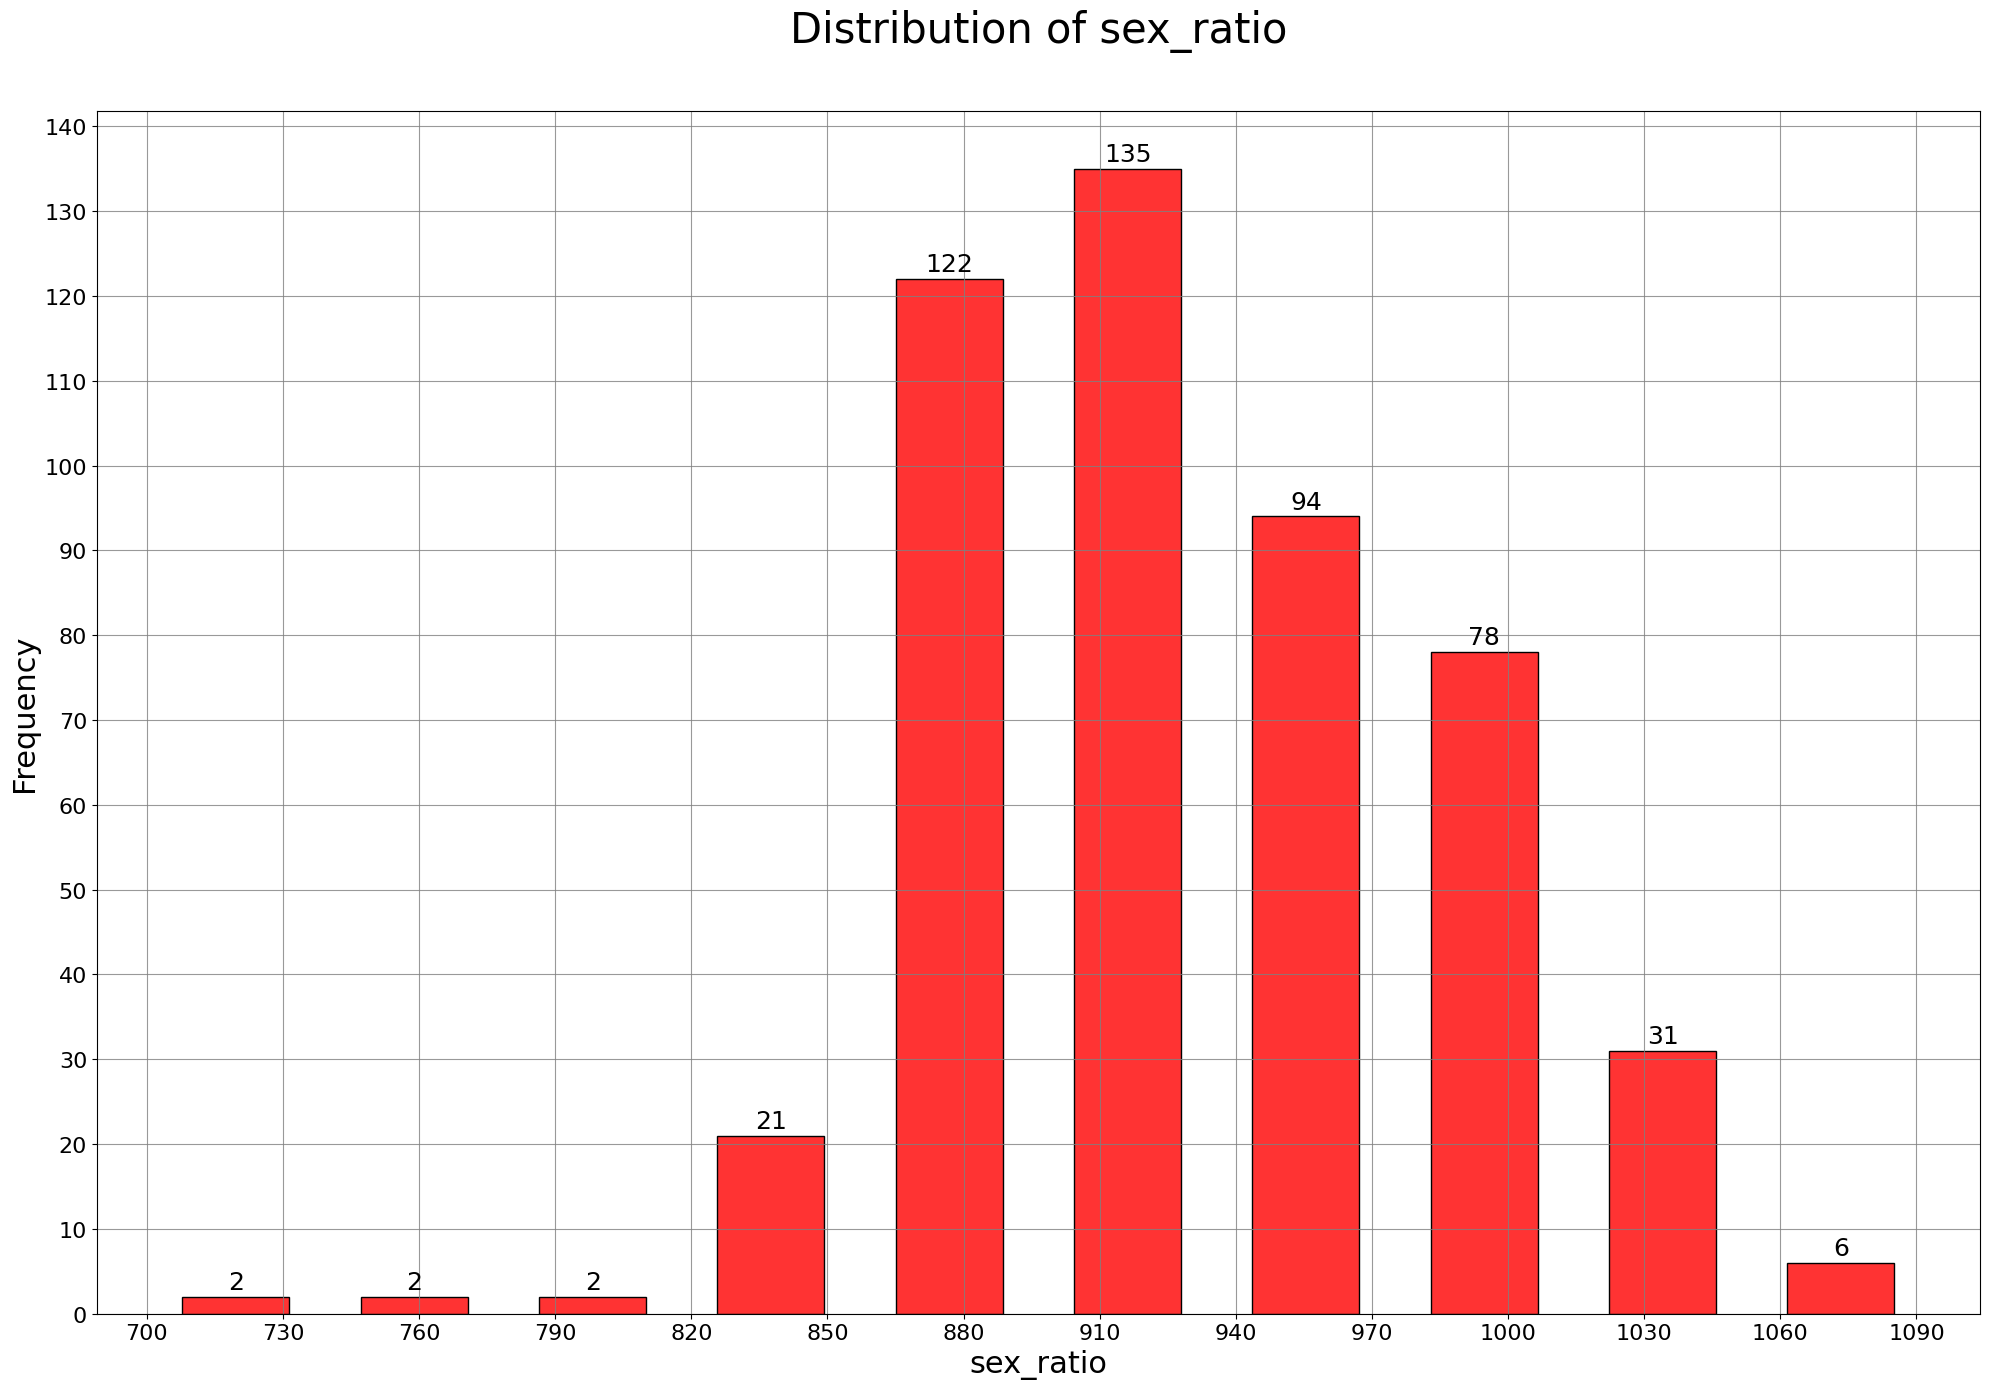

In [235]:
plt.figure(figsize=(20,14), facecolor="white")

ax=sns.histplot(df['sex_ratio'], bins=10, edgecolor='black', alpha=0.8,color='red',shrink=0.6)

plt.title("Distribution of sex_ratio", fontsize=30, pad=50)
plt.xlabel("sex_ratio", fontsize=22)
plt.ylabel("Frequency", fontsize=22)

plt.xticks(range(700,1095,30),fontsize=16)
plt.yticks(range(0,150,10),fontsize=16)

plt.grid(alpha=0.8,color='gray')

plt.tight_layout()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=18, padding=2)

plt.show()

In [236]:
df['child_sex_ratio'].describe()

count     493.000000
mean      902.332657
std        49.794689
min       762.000000
25%       868.000000
50%       903.000000
75%       942.000000
max      1185.000000
Name: child_sex_ratio, dtype: float64

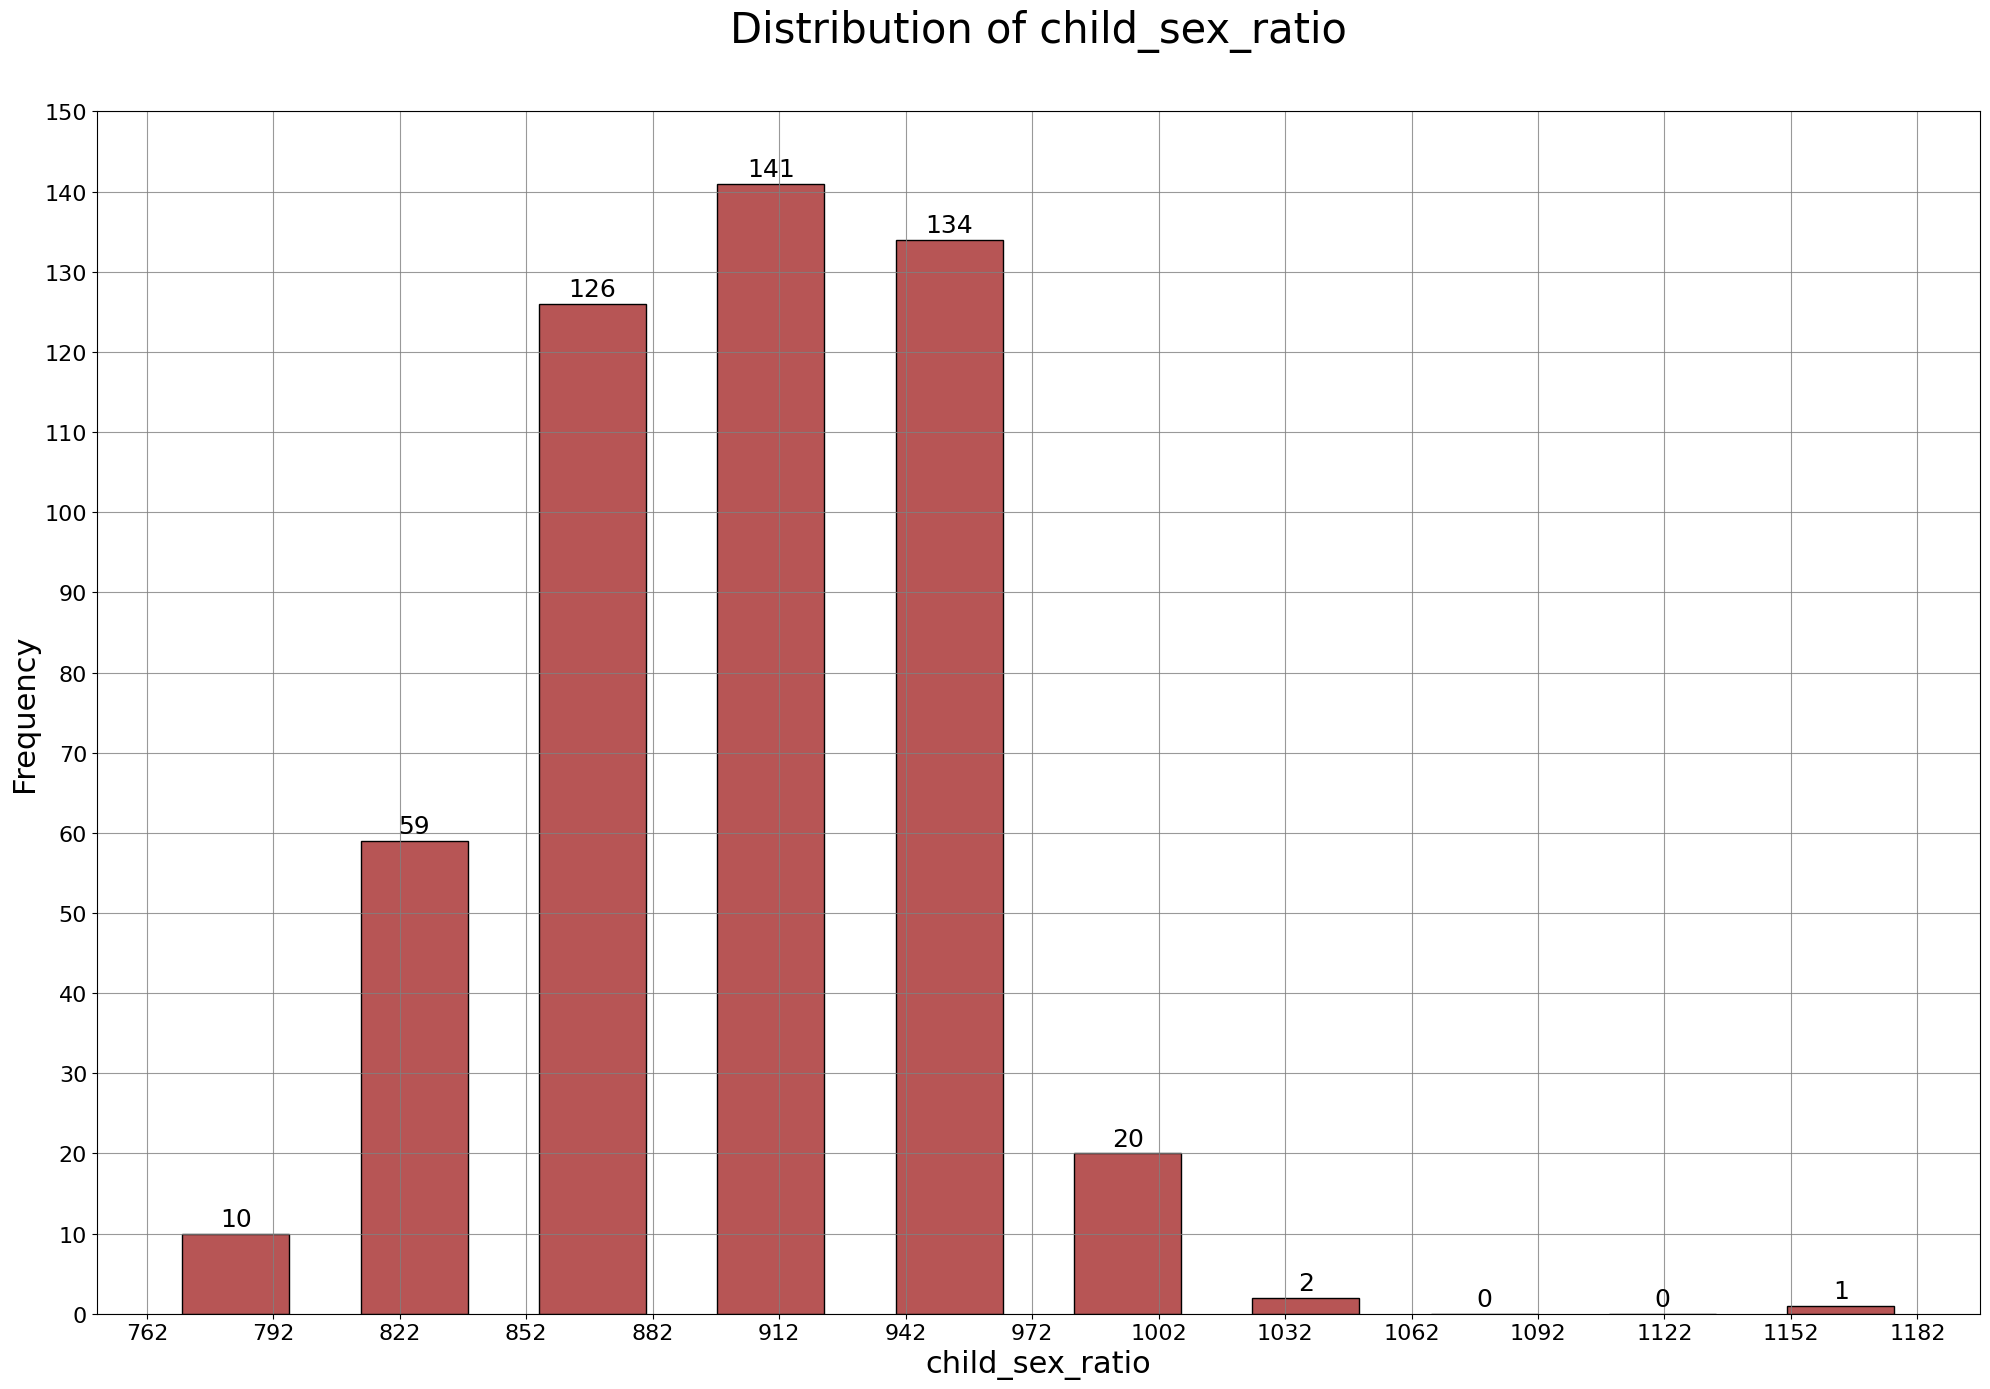

In [237]:
plt.figure(figsize=(20,14), facecolor="white")

ax=sns.histplot(df['child_sex_ratio'], bins=10, edgecolor='black', alpha=0.8,color='brown',shrink=0.6)

plt.title("Distribution of child_sex_ratio", fontsize=30, pad=50)
plt.xlabel("child_sex_ratio", fontsize=22)
plt.ylabel("Frequency", fontsize=22)

plt.xticks(range(762,1200,30),fontsize=16)
plt.yticks(range(0,160,10),fontsize=16)

plt.grid(alpha=0.8,color='gray')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=18, padding=2)

plt.tight_layout()
plt.show()

In [238]:
df['effective_literacy_rate_total'].describe()

count    493.000000
mean      85.131460
std        6.186345
min       49.510000
25%       81.750000
50%       85.970000
75%       89.330000
max       98.800000
Name: effective_literacy_rate_total, dtype: float64

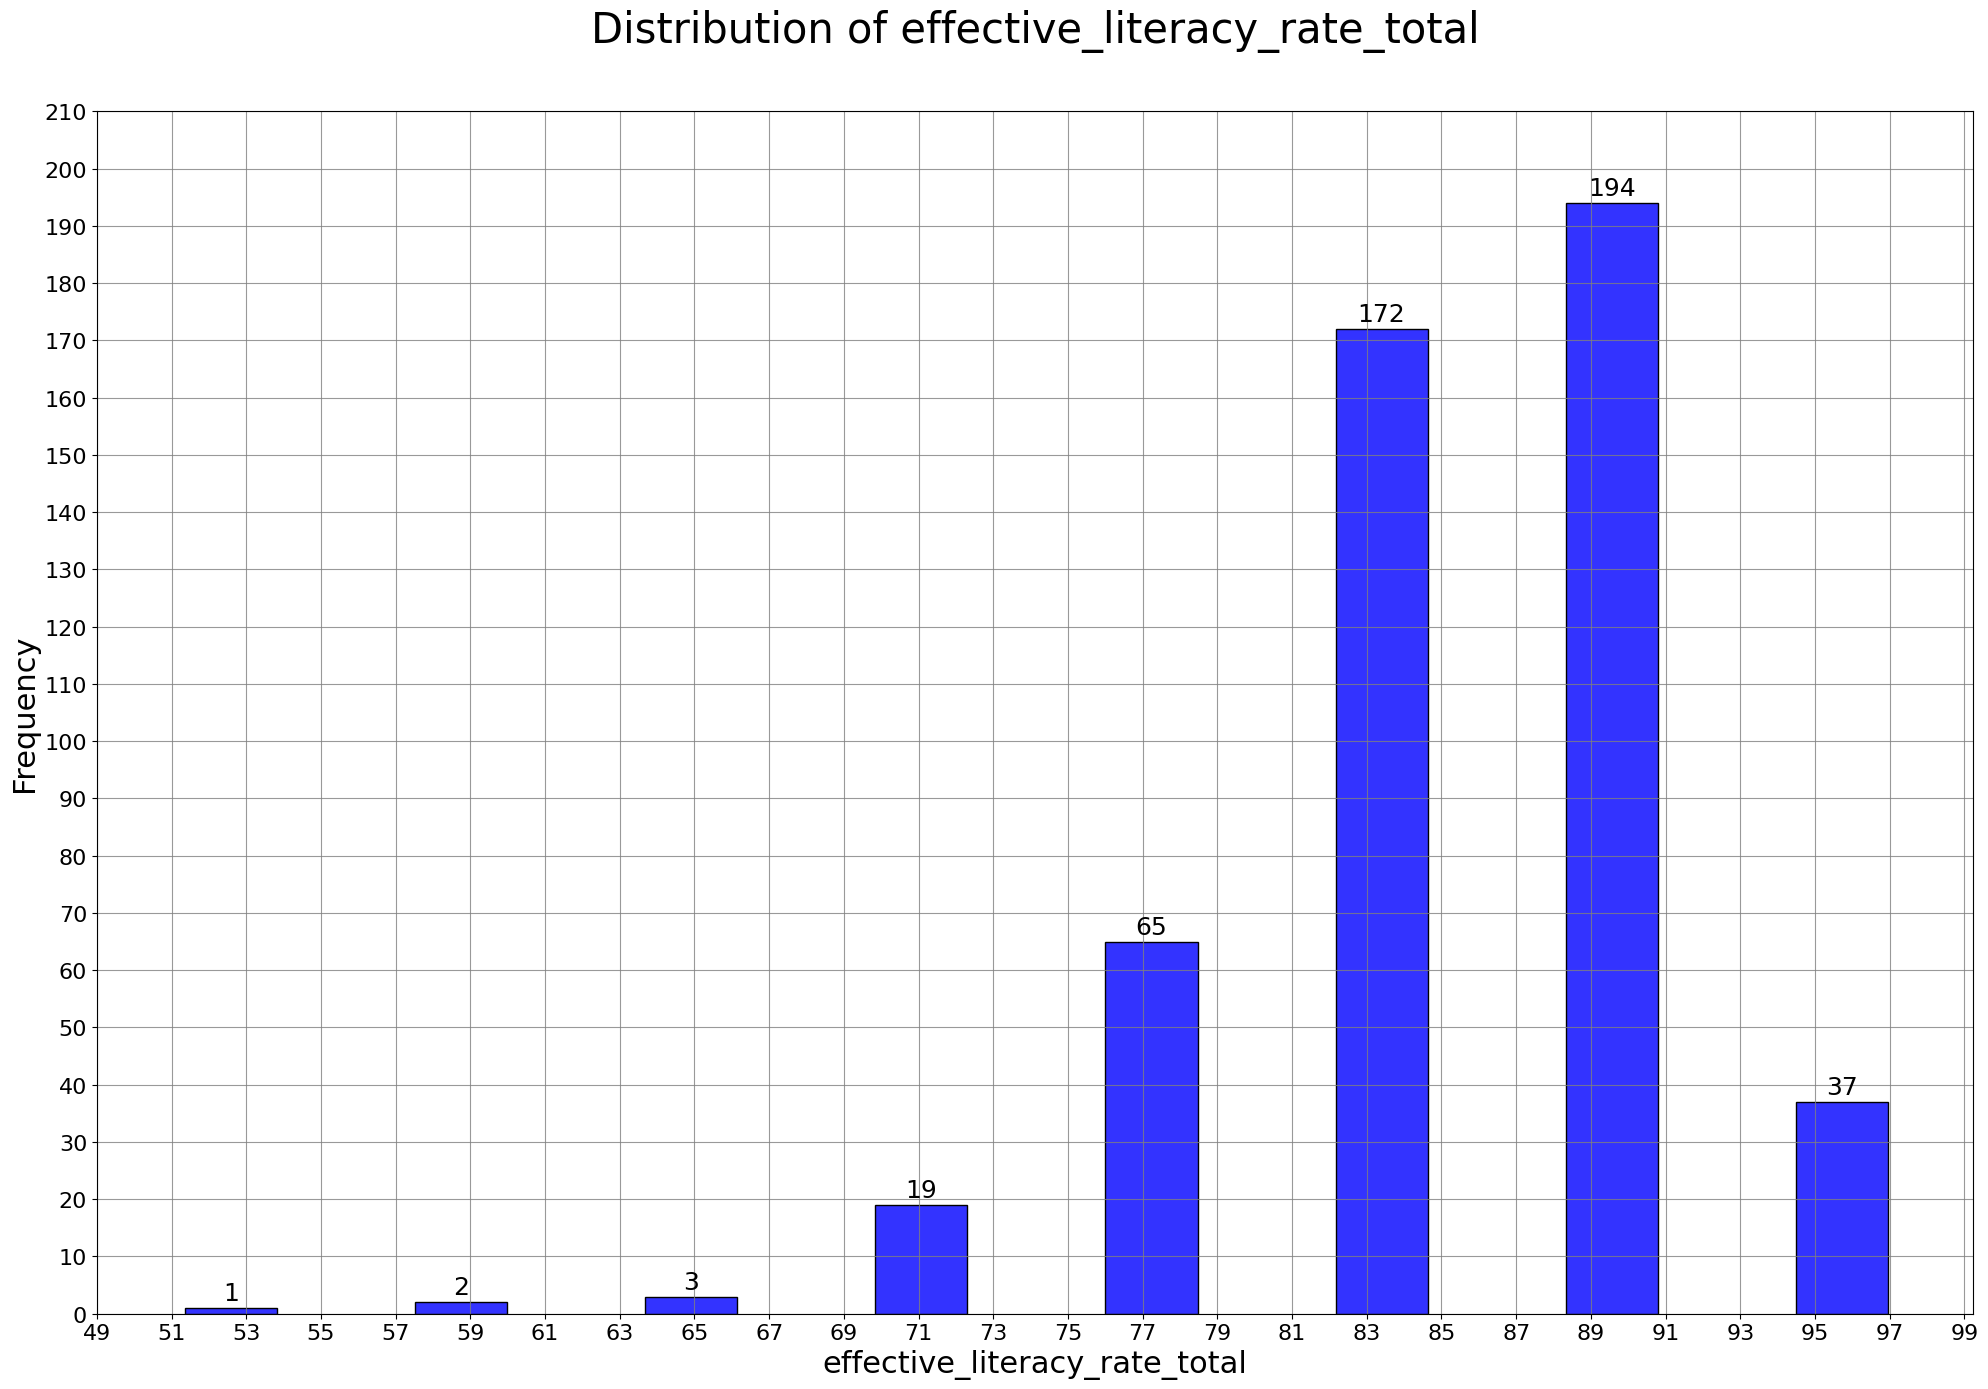

In [239]:
plt.figure(figsize=(20,14), facecolor="white")

ax=sns.histplot(df['effective_literacy_rate_total'], bins=8, edgecolor='black', alpha=0.8,color='blue',shrink=0.4)

plt.title("Distribution of effective_literacy_rate_total", fontsize=30, pad=50)
plt.xlabel("effective_literacy_rate_total", fontsize=22)
plt.ylabel("Frequency", fontsize=22)

plt.xticks(range(49,100,2),fontsize=16)
plt.yticks(range(0,220,10),fontsize=16)

plt.grid(alpha=0.8,color='gray')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=18, padding=2)

plt.tight_layout()
plt.show()

In [240]:
df['effective_literacy_rate_male'].describe()

count    493.000000
mean      89.920162
std        5.377492
min       52.270000
25%       87.280000
50%       91.180000
75%       93.400000
max       99.300000
Name: effective_literacy_rate_male, dtype: float64

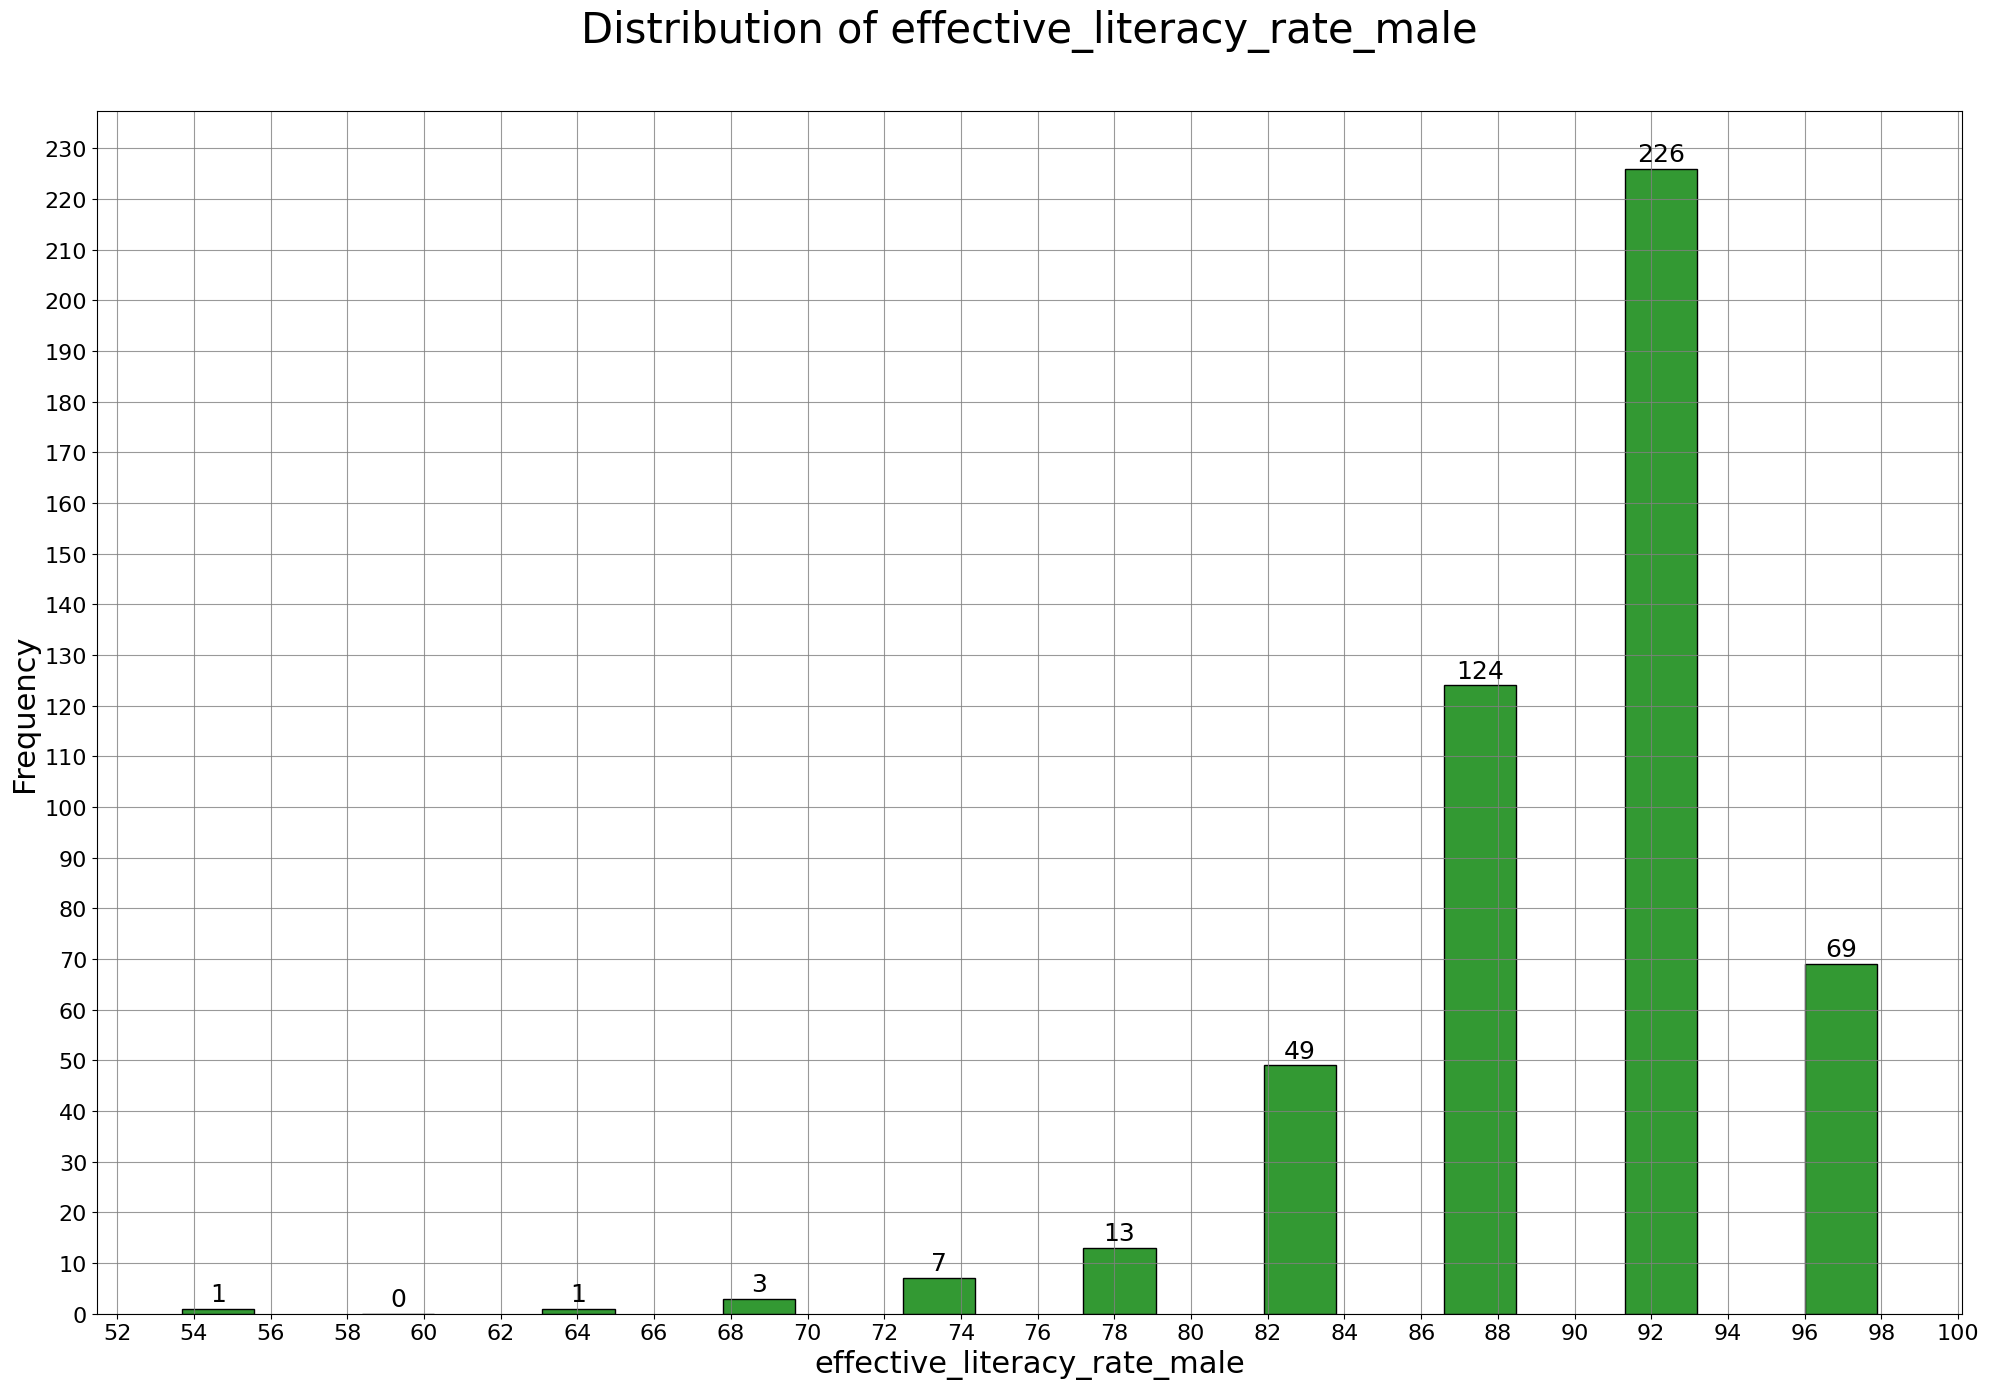

In [241]:
plt.figure(figsize=(20,14), facecolor="white")

ax=sns.histplot(df['effective_literacy_rate_male'], bins=10, edgecolor='black', alpha=0.8,color='green',shrink=0.4)

plt.title("Distribution of effective_literacy_rate_male", fontsize=30, pad=50)
plt.xlabel("effective_literacy_rate_male", fontsize=22)
plt.ylabel("Frequency", fontsize=22)

plt.xticks(range(52,102,2),fontsize=16)
plt.yticks(range(0,240,10),fontsize=16)

plt.grid(alpha=0.8,color='gray')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=18, padding=2)
plt.tight_layout()
plt.show()

In [242]:
df['effective_literacy_rate_female'].describe()

count    493.000000
mean      79.967181
std        7.577825
min       46.450000
25%       75.800000
50%       80.920000
75%       85.400000
max       98.310000
Name: effective_literacy_rate_female, dtype: float64

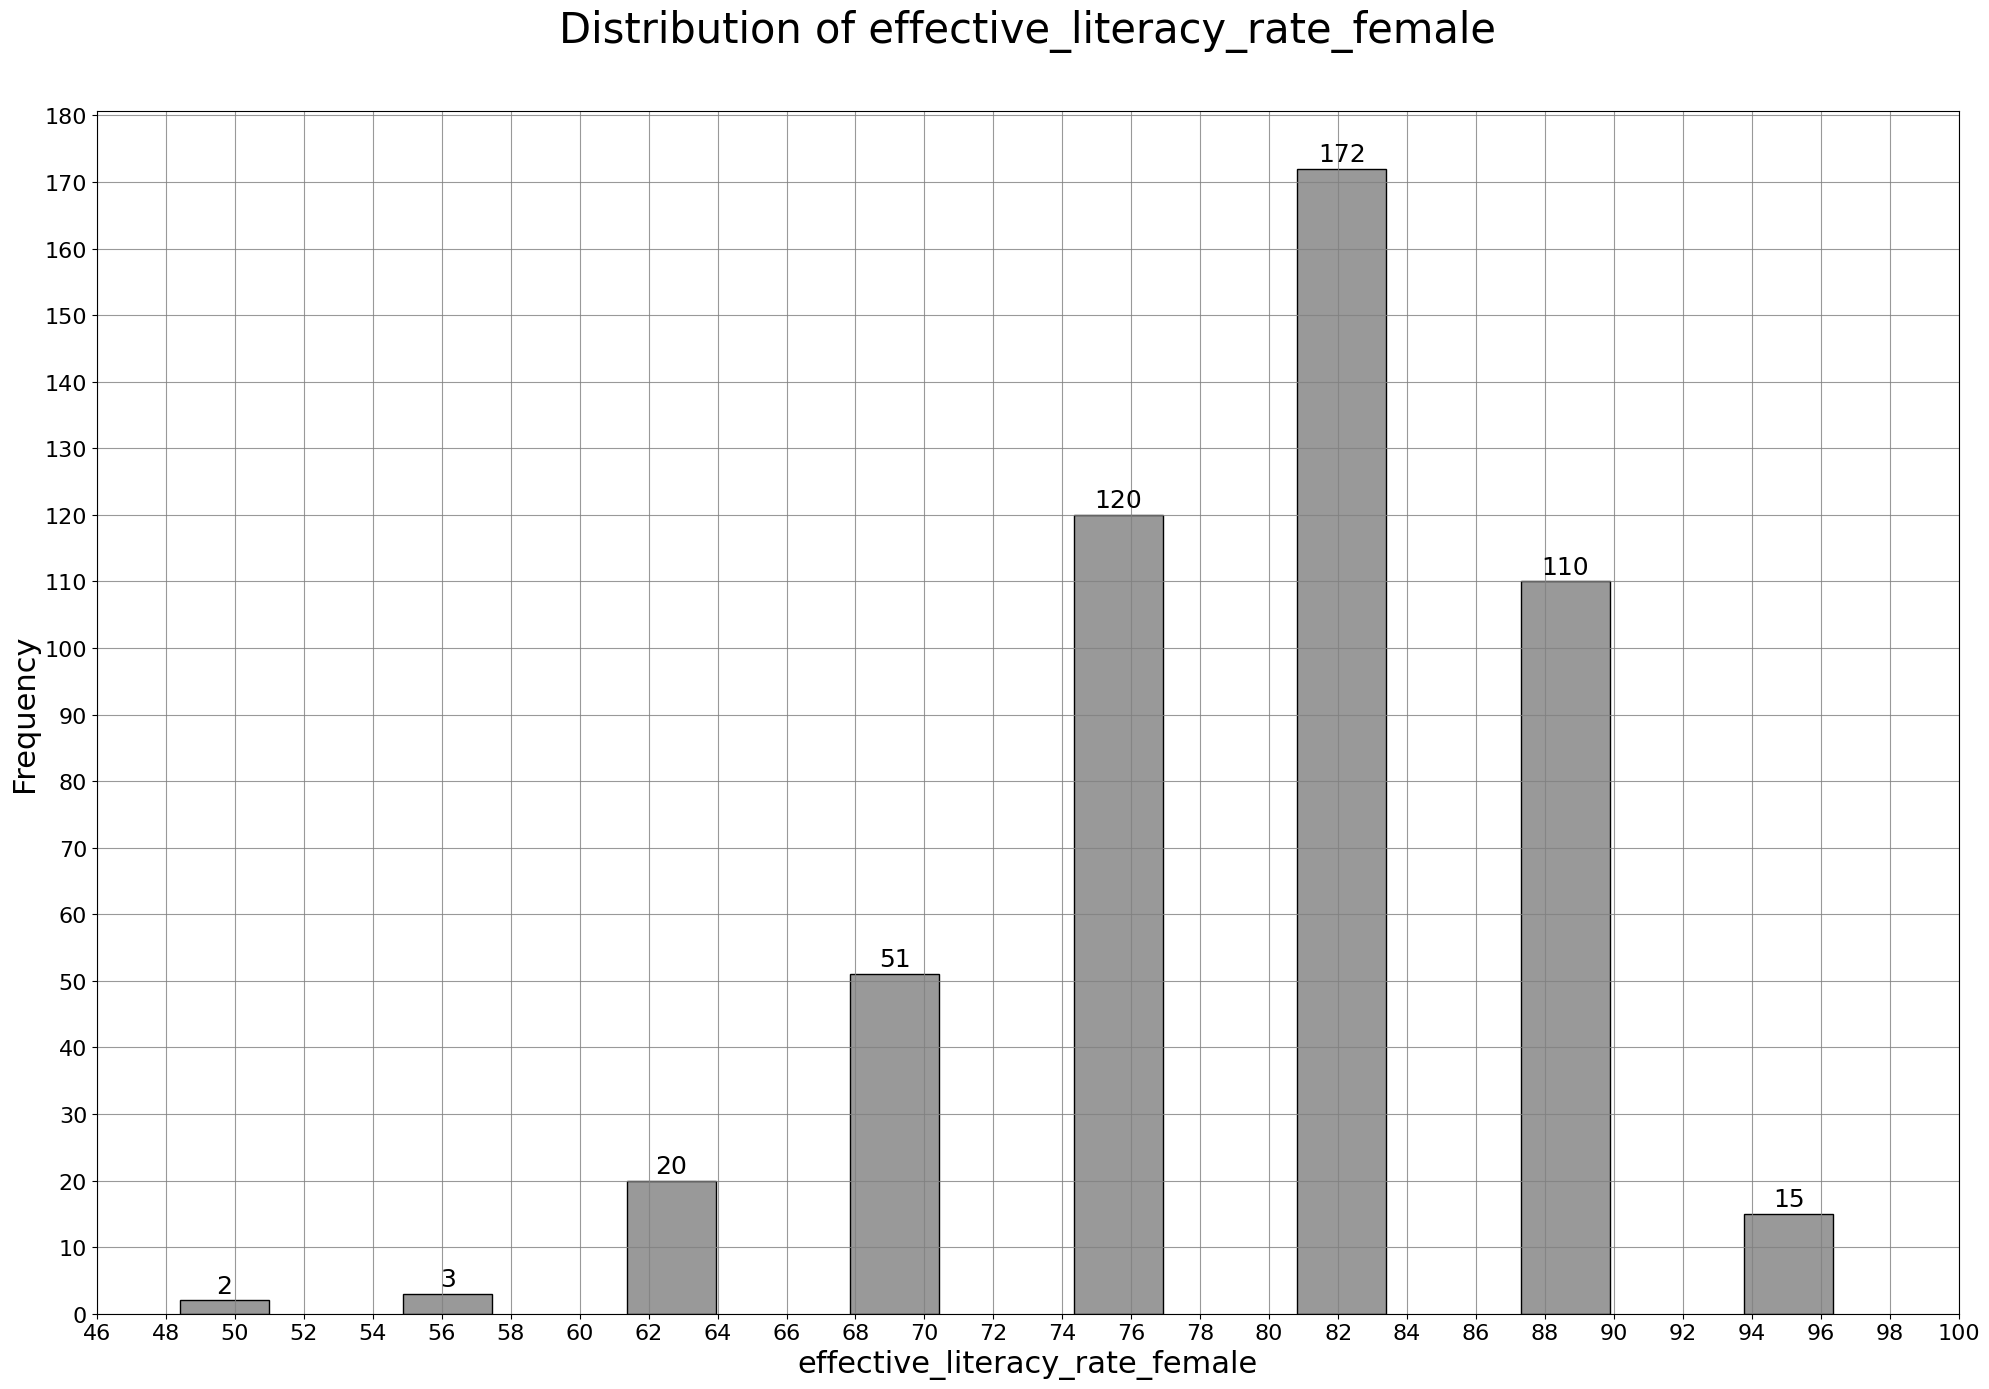

In [243]:
plt.figure(figsize=(20,14), facecolor="white")

ax=sns.histplot(df['effective_literacy_rate_female'], bins=8, edgecolor='black', alpha=0.8,color='gray',shrink=0.4)

plt.title("Distribution of effective_literacy_rate_female", fontsize=30, pad=50)
plt.xlabel("effective_literacy_rate_female", fontsize=22)
plt.ylabel("Frequency", fontsize=22)

plt.xticks(range(46,102,2),fontsize=16)
plt.yticks(range(0,190,10),fontsize=16)

plt.grid(alpha=0.8,color='gray')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=18, padding=2)
plt.tight_layout()
plt.show()

In [244]:
df['total_graduates'].describe()

count    4.930000e+02
mean     6.620236e+04
std      1.778187e+05
min      2.532000e+03
25%      1.527700e+04
50%      2.395900e+04
75%      5.036700e+04
max      2.221137e+06
Name: total_graduates, dtype: float64

In [245]:
df['male_graduates'].describe()

count    4.930000e+02
mean     3.771556e+04
std      9.849574e+04
min      1.703000e+03
25%      9.289000e+03
50%      1.404900e+04
75%      2.787200e+04
max      1.210040e+06
Name: male_graduates, dtype: float64

In [246]:
df['female_graduates'].describe()

count    4.930000e+02
mean     2.848680e+04
std      7.951556e+04
min      8.290000e+02
25%      6.114000e+03
50%      9.558000e+03
75%      2.086600e+04
max      1.011097e+06
Name: female_graduates, dtype: float64

In [247]:
df['population_female'].describe()

count    4.930000e+02
mean     2.137656e+05
std      4.848622e+05
min      4.512600e+04
25%      6.041100e+04
50%      8.776800e+04
75%      1.700260e+05
max      5.741632e+06
Name: population_female, dtype: float64

In [248]:
df['population_male'].describe()

count    4.930000e+02
mean     2.343468e+05
std      5.487786e+05
min      5.020100e+04
25%      6.638400e+04
50%      9.665500e+04
75%      1.750550e+05
max      6.736815e+06
Name: population_male, dtype: float64

In [249]:
df['population_total'].describe()

count    4.930000e+02
mean     4.481124e+05
std      1.033228e+06
min      1.000360e+05
25%      1.261420e+05
50%      1.841330e+05
75%      3.490330e+05
max      1.247845e+07
Name: population_total, dtype: float64

In [250]:
df['dist_code'].describe()

count    493.000000
mean      16.782961
std       15.566131
min        1.000000
25%        7.000000
50%       13.000000
75%       21.000000
max       99.000000
Name: dist_code, dtype: float64

In [251]:
df['state_name'].value_counts()

state_name
UTTAR PRADESH                63
WEST BENGAL                  61
MAHARASHTRA                  43
ANDHRA PRADESH               42
TAMIL NADU                   32
MADHYA PRADESH               32
RAJASTHAN                    29
GUJARAT                      29
KARNATAKA                    26
BIHAR                        26
HARYANA                      20
PUNJAB                       16
NCT OF DELHI                 15
JHARKHAND                    10
ORISSA                       10
CHHATTISGARH                  9
KERALA                        7
UTTARAKHAND                   6
ASSAM                         4
JAMMU & KASHMIR               3
PUDUCHERRY                    2
MIZORAM                       1
TRIPURA                       1
CHANDIGARH                    1
NAGALAND                      1
MANIPUR                       1
ANDAMAN & NICOBAR ISLANDS     1
MEGHALAYA                     1
HIMACHAL PRADESH              1
Name: count, dtype: int64

In [252]:
df['state_code'].describe()

count    493.000000
mean      18.643002
std        9.297168
min        1.000000
25%        9.000000
50%       19.000000
75%       27.000000
max       35.000000
Name: state_code, dtype: float64

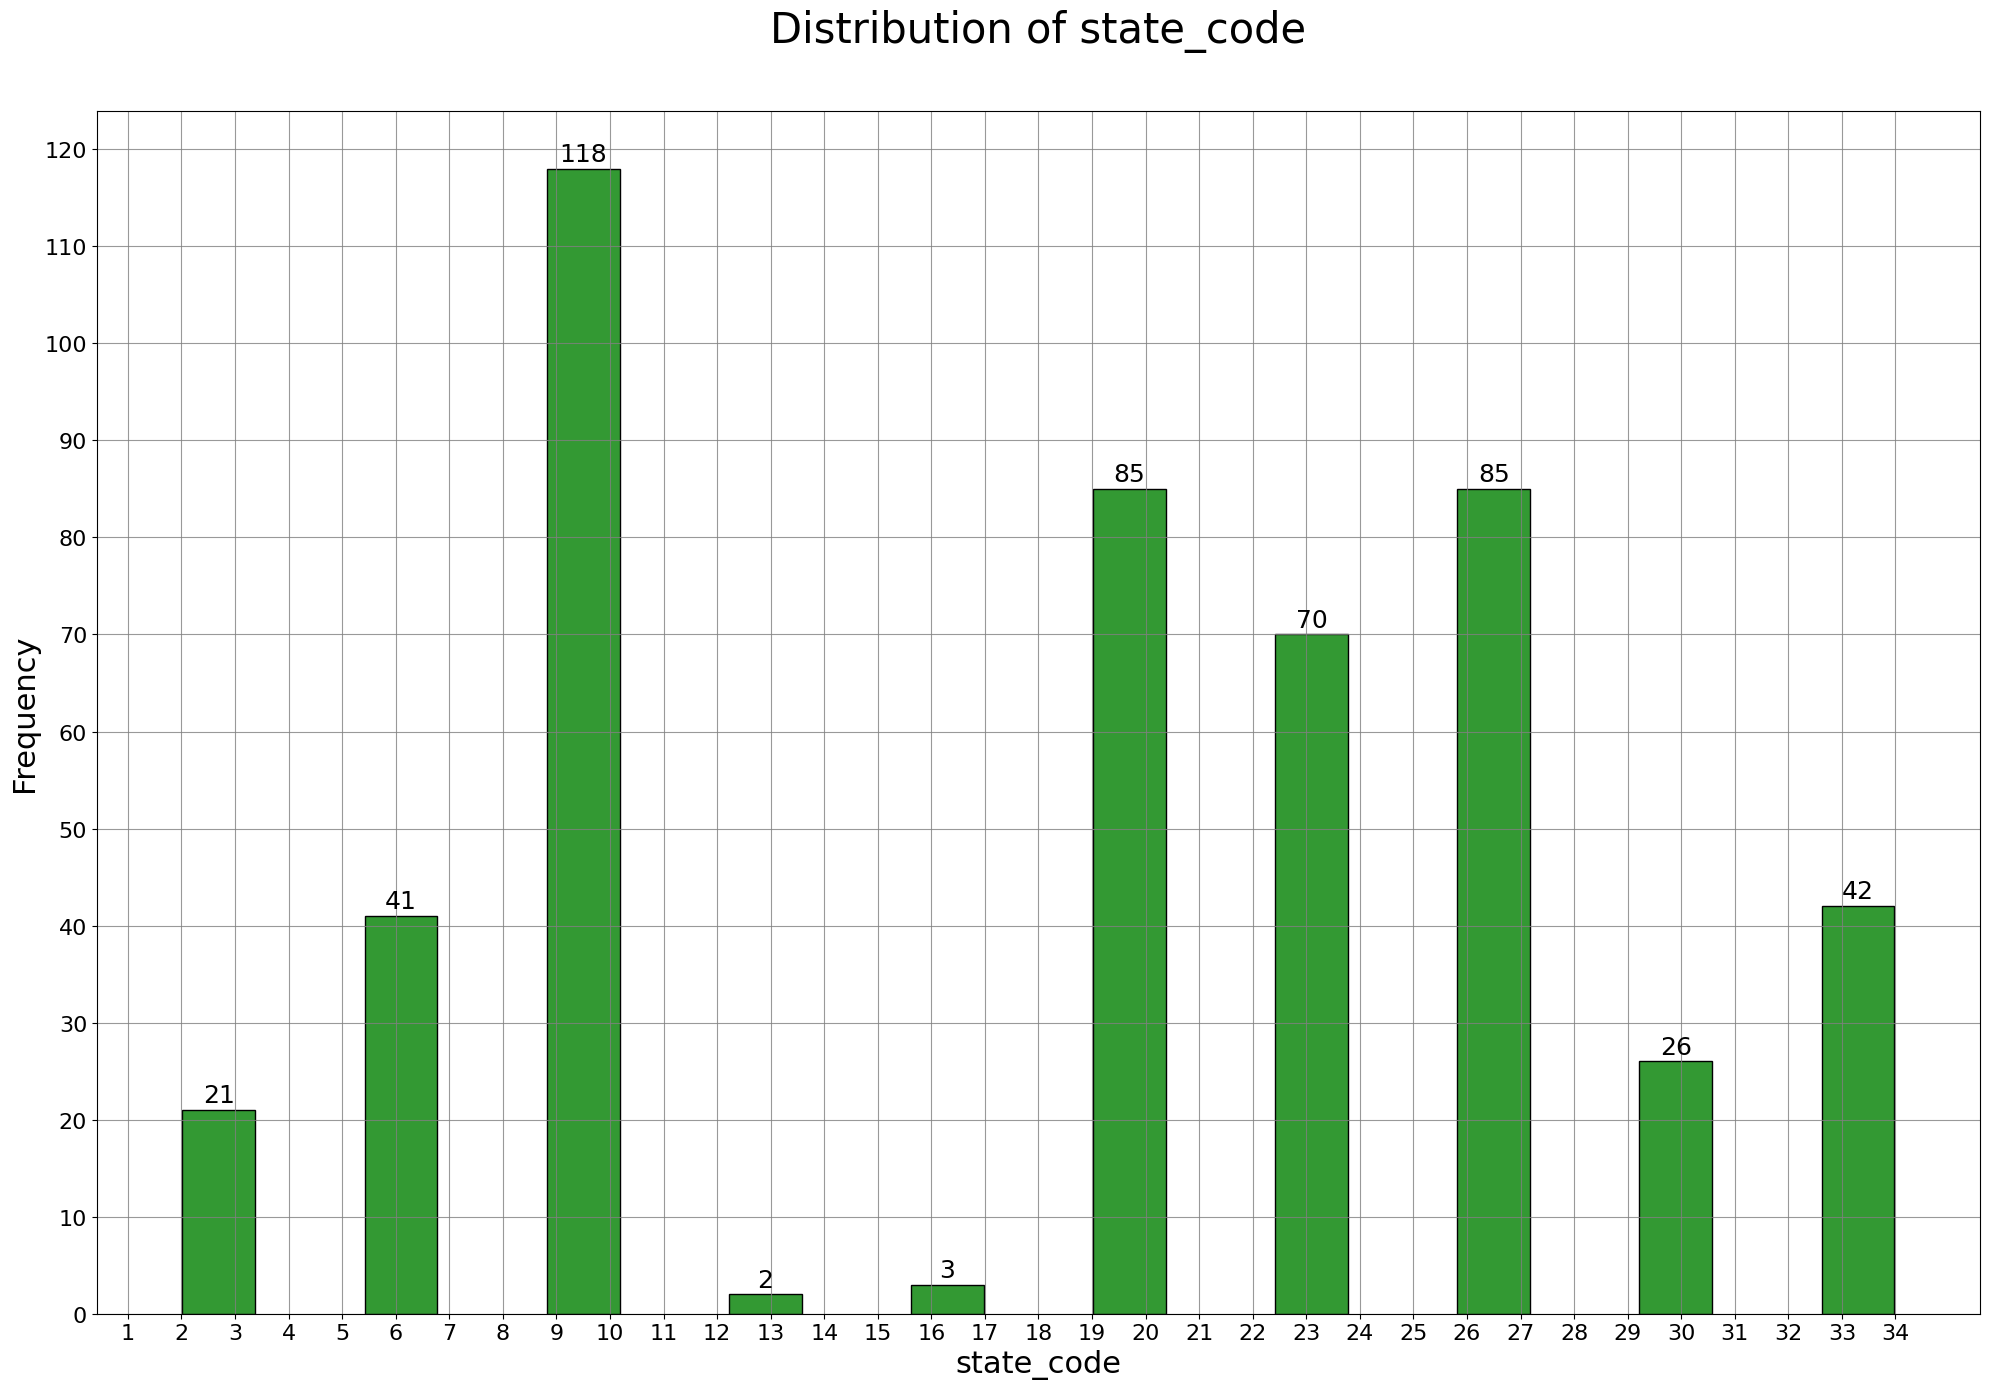

In [253]:
plt.figure(figsize=(20,14), facecolor="white")

ax=sns.histplot(df['state_code'], bins=10, edgecolor='black', alpha=0.8,color='green',shrink=0.4)

plt.title("Distribution of state_code", fontsize=30, pad=50)
plt.xlabel("state_code", fontsize=22)
plt.ylabel("Frequency", fontsize=22)

plt.xticks(range(1,35,1),fontsize=16)
plt.yticks(range(0,130,10),fontsize=16)

plt.grid(alpha=0.8,color='gray')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=18, padding=2)

plt.tight_layout()
plt.show()

In [254]:
df['name_of_city'].value_counts()

name_of_city
Aurangabad     2
Adityapur      1
Adoni          1
Agartala       1
Agra           1
              ..
Bagalkot       1
Bahadurgarh    1
Baharampur     1
Bahraich       1
Achalpur       1
Name: count, Length: 492, dtype: int64

# biavariate analysis

In [255]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 493 entries, 0 to 492
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   name_of_city                    493 non-null    object 
 1   state_code                      493 non-null    int64  
 2   state_name                      493 non-null    object 
 3   dist_code                       493 non-null    int64  
 4   population_total                493 non-null    int64  
 5   population_male                 493 non-null    int64  
 6   population_female               493 non-null    int64  
 7   0-6_population_total            493 non-null    int64  
 8   0-6_population_male             493 non-null    int64  
 9   0-6_population_female           493 non-null    int64  
 10  literates_total                 493 non-null    int64  
 11  literates_male                  493 non-null    int64  
 12  literates_female                493 

# name_of_city and total_graduates

In [256]:
df.groupby(['name_of_city'])['total_graduates'].mean()

name_of_city
Abohar           16287.0
Achalpur          8863.0
Adilabad         10565.0
Adityapur        19225.0
Adoni            11902.0
                  ...   
Vizianagaram     30656.0
Warangal        109613.0
Wardha           19363.0
Yamunanagar      29803.0
Yavatmal         13511.0
Name: total_graduates, Length: 492, dtype: float64

C:\Users\Mega\AppData\Local\Temp\ipykernel_7340\1153107045.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(


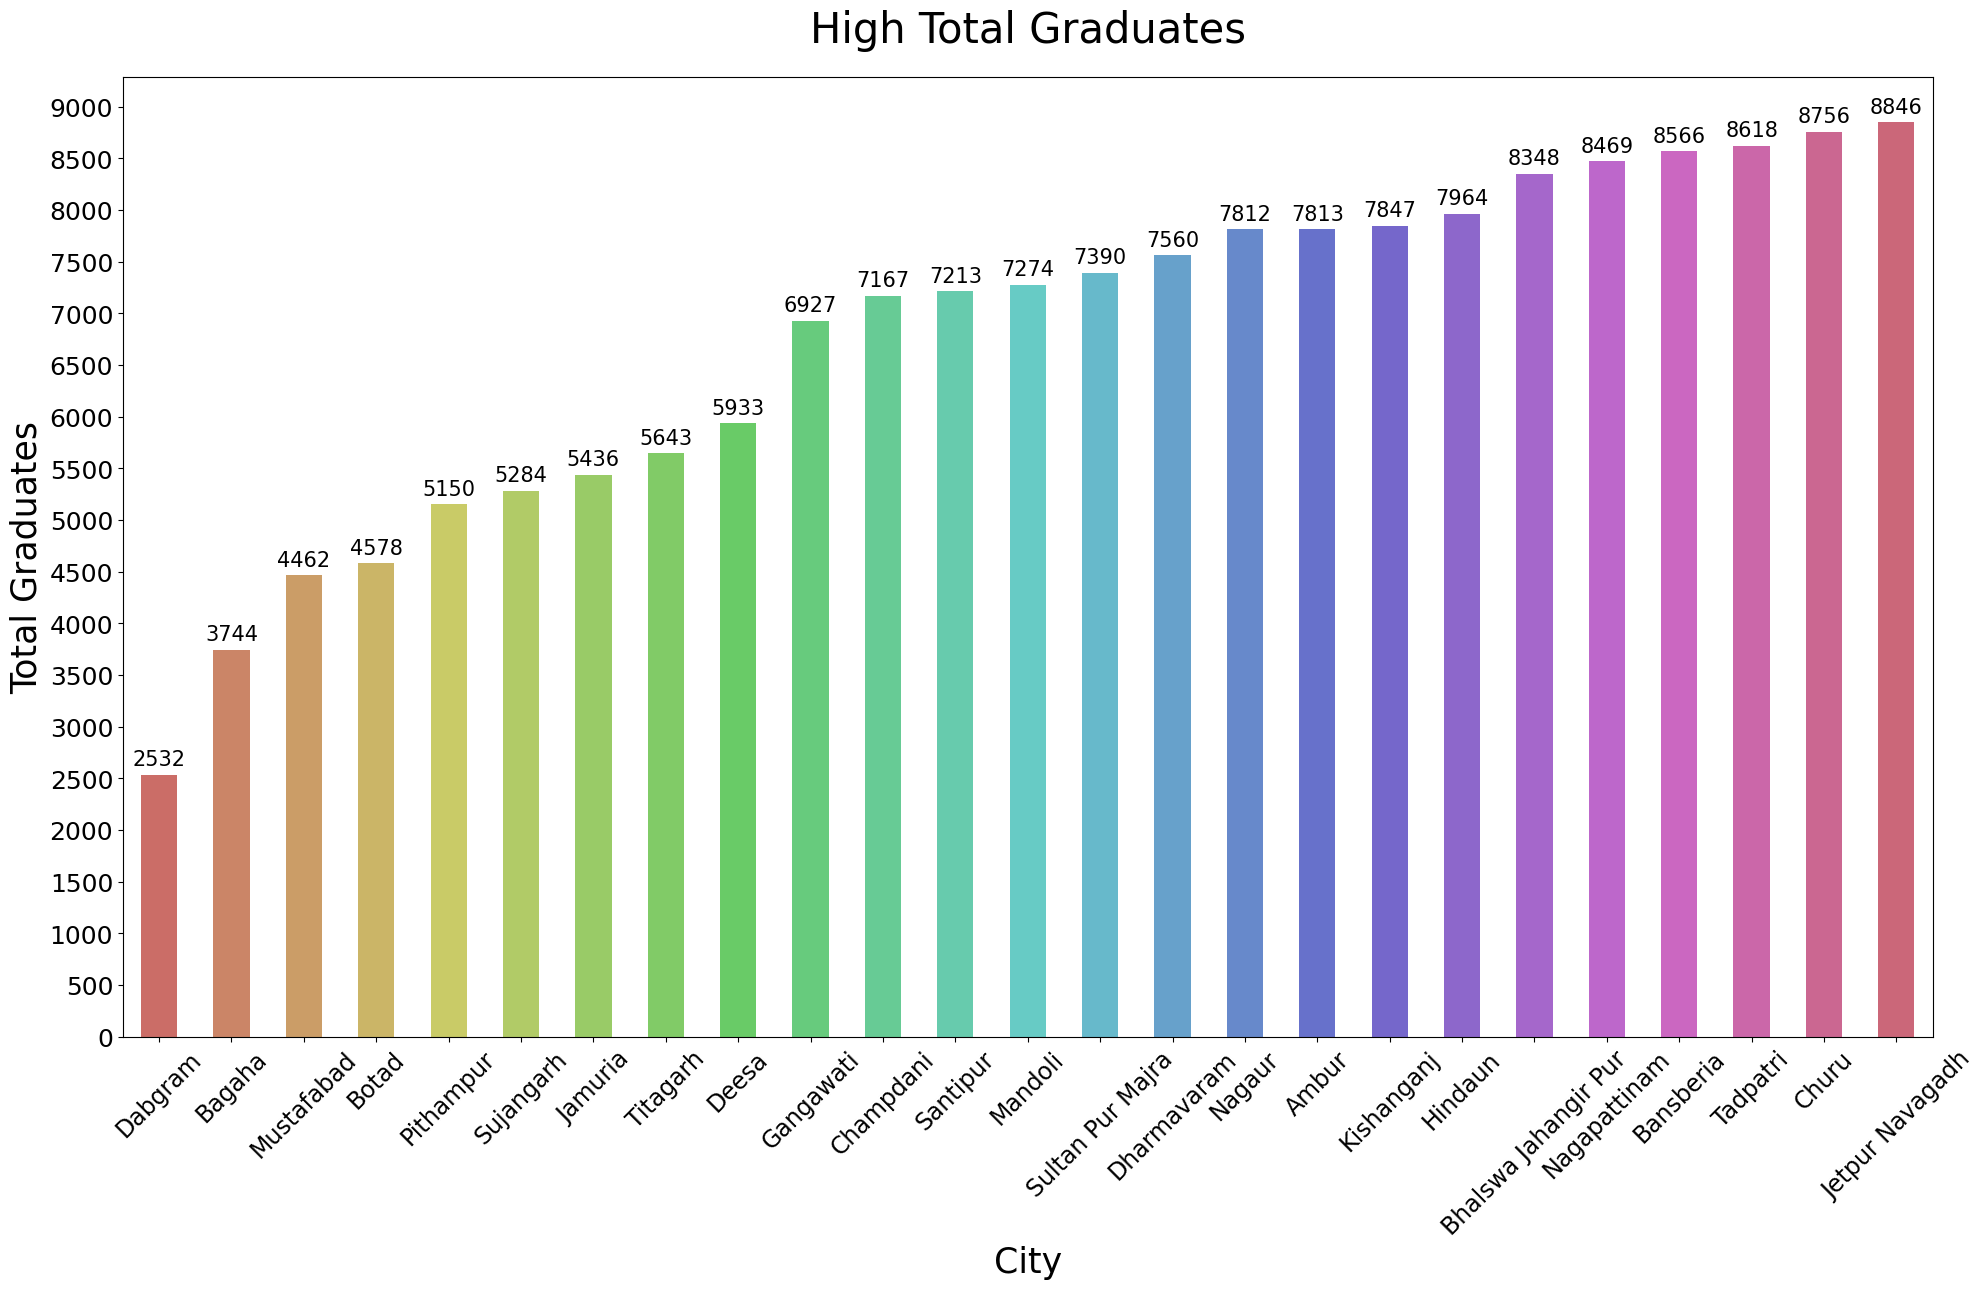

In [257]:
plt.figure(figsize=(20,13))
top_cities = df.sort_values('total_graduates', ascending=True).head(25)

ax=sns.barplot(
    x='name_of_city',
    y='total_graduates',
    palette='hls',
    data=top_cities,width=0.5
)

plt.title('High Total Graduates', fontsize=30, pad=25)
plt.ylabel('Total Graduates', fontsize=25)
plt.xlabel('City', fontsize=25)
plt.xticks(rotation=45, fontsize=17)
plt.yticks(range(0,9500,500),fontsize=18)
plt.tight_layout()
# إضافة الأرقام فوق الأعمدة
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=15, padding=4)

plt.show()


# name_of_city and effective_literacy_rate_total

In [258]:
df.groupby(['name_of_city'])['effective_literacy_rate_total'].mean()

name_of_city
Abohar          79.86
Achalpur        91.99
Adilabad        80.51
Adityapur       83.46
Adoni           68.38
                ...  
Vizianagaram    81.85
Warangal        84.16
Wardha          94.05
Yamunanagar     85.91
Yavatmal        91.81
Name: effective_literacy_rate_total, Length: 492, dtype: float64

C:\Users\Mega\AppData\Local\Temp\ipykernel_7340\1679961362.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


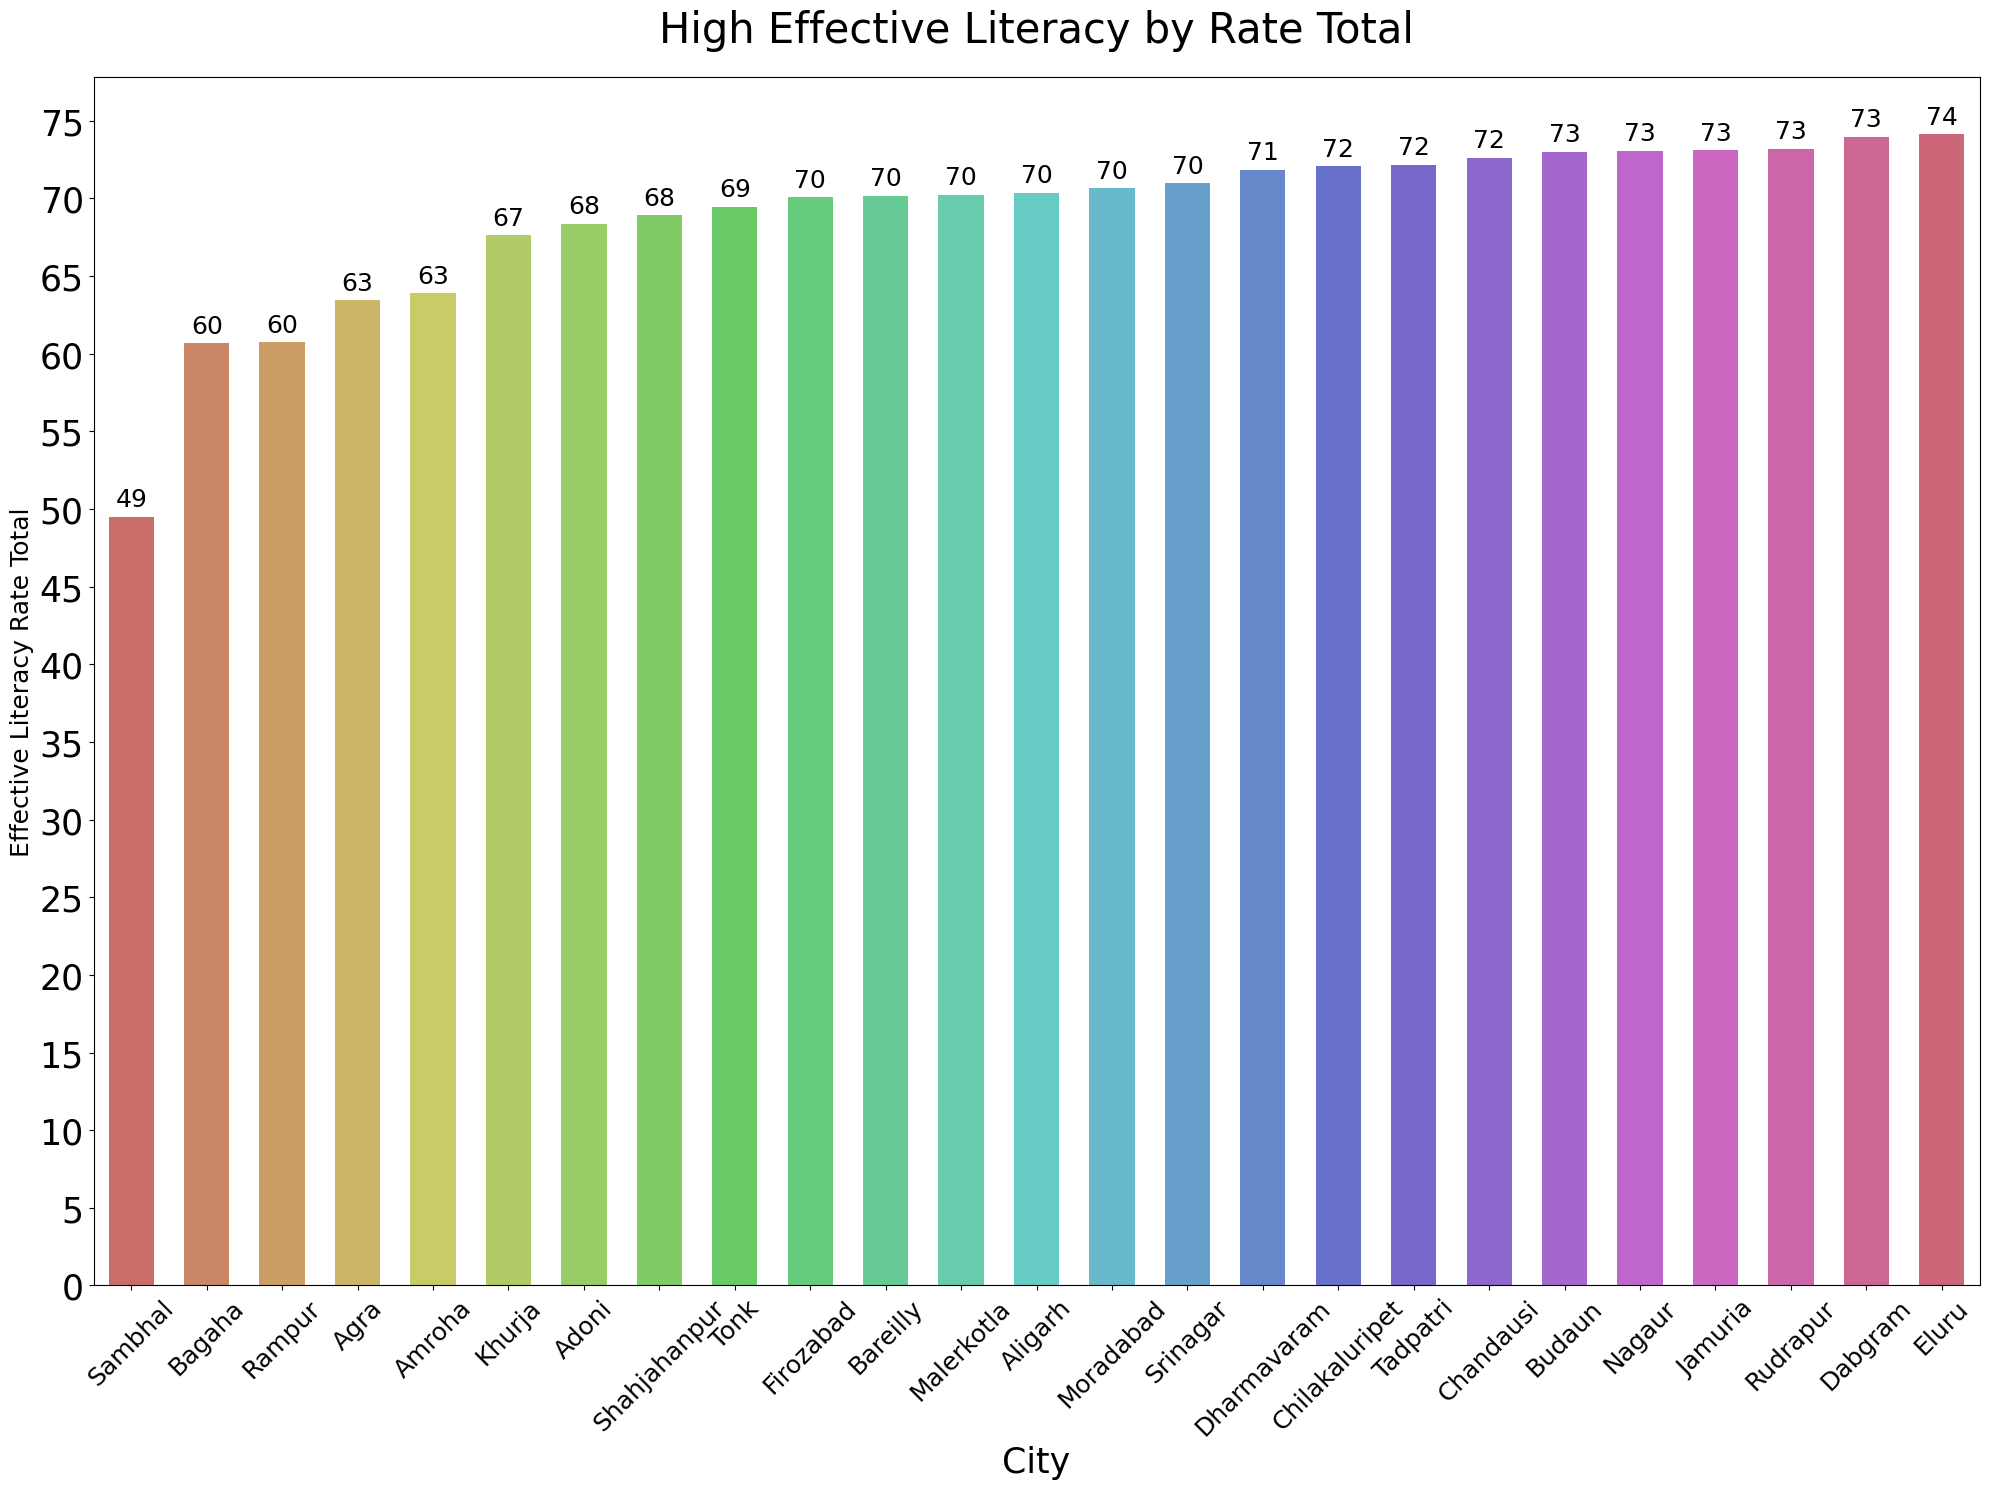

In [259]:
plt.figure(figsize=(20,15))

top_cities = df.sort_values('effective_literacy_rate_total', ascending=True).head(25)

ax = sns.barplot(
    x='name_of_city',
    y='effective_literacy_rate_total',   
    palette='hls',
    data=top_cities,
    width=0.6
)

plt.xticks(rotation=45, fontsize=18)
plt.title('High Effective Literacy by Rate Total', fontsize=30, pad=25)
plt.yticks(range(0,80,5),fontsize=25)
plt.ylabel('Effective Literacy Rate Total', fontsize=18)
plt.xlabel('City', fontsize=25)
plt.tight_layout()
# إضافة الأرقام فوق الأعمدة
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=18, padding=4)
plt.show()


# multivariate analysis

In [260]:
corr=df[['0-6_population_total','0-6_population_male','0-6_population_female','literates_total','literates_male','literates_female','sex_ratio',
    'child_sex_ratio','effective_literacy_rate_total','effective_literacy_rate_male','effective_literacy_rate_female',
    'total_graduates','male_graduates','female_graduates']].corr()

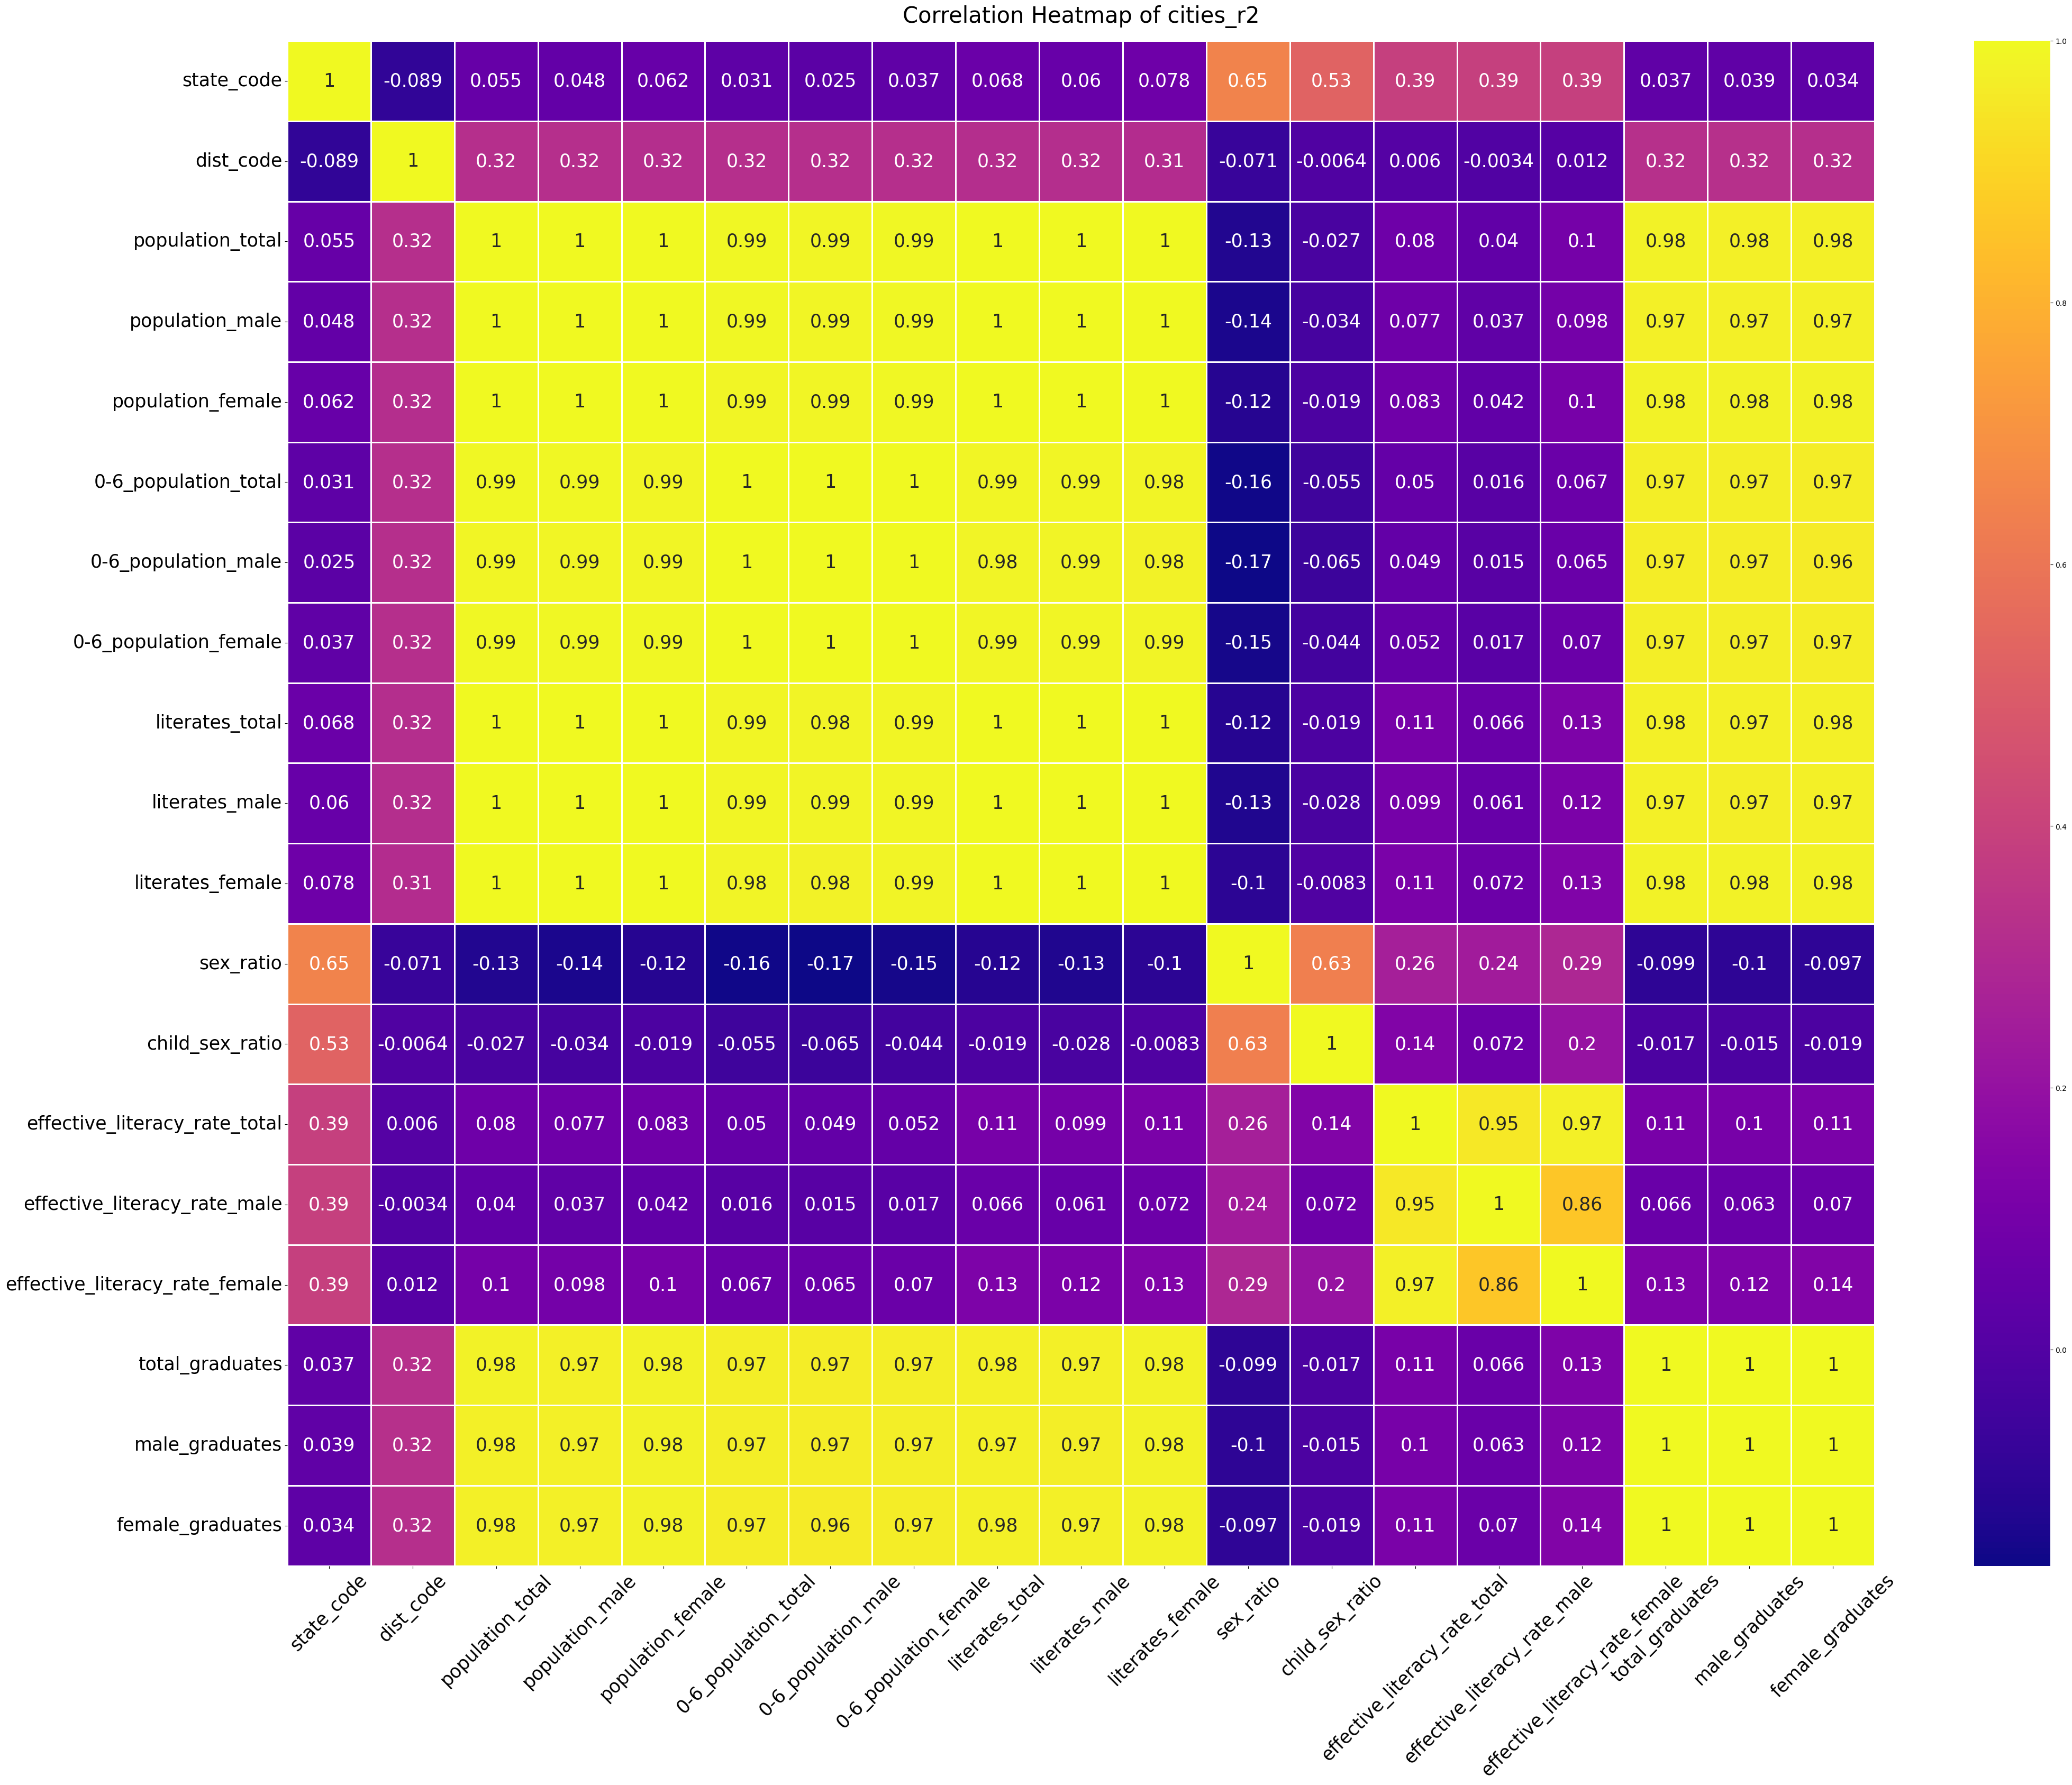

In [261]:
correlation = df.corr(numeric_only=True)
plt.figure(figsize=(40,32))
sns.heatmap(correlation, annot=True, cmap="plasma", linewidths=0.8,annot_kws={'size':25})
plt.title('Correlation Heatmap of cities_r2',fontsize=30,pad=25)
plt.tight_layout()
plt.xticks(fontsize=25,rotation=45)
plt.yticks(fontsize=25)
plt.show()

C:\Users\Mega\AppData\Local\Temp\ipykernel_7340\224716781.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(
C:\Users\Mega\AppData\Local\Temp\ipykernel_7340\224716781.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


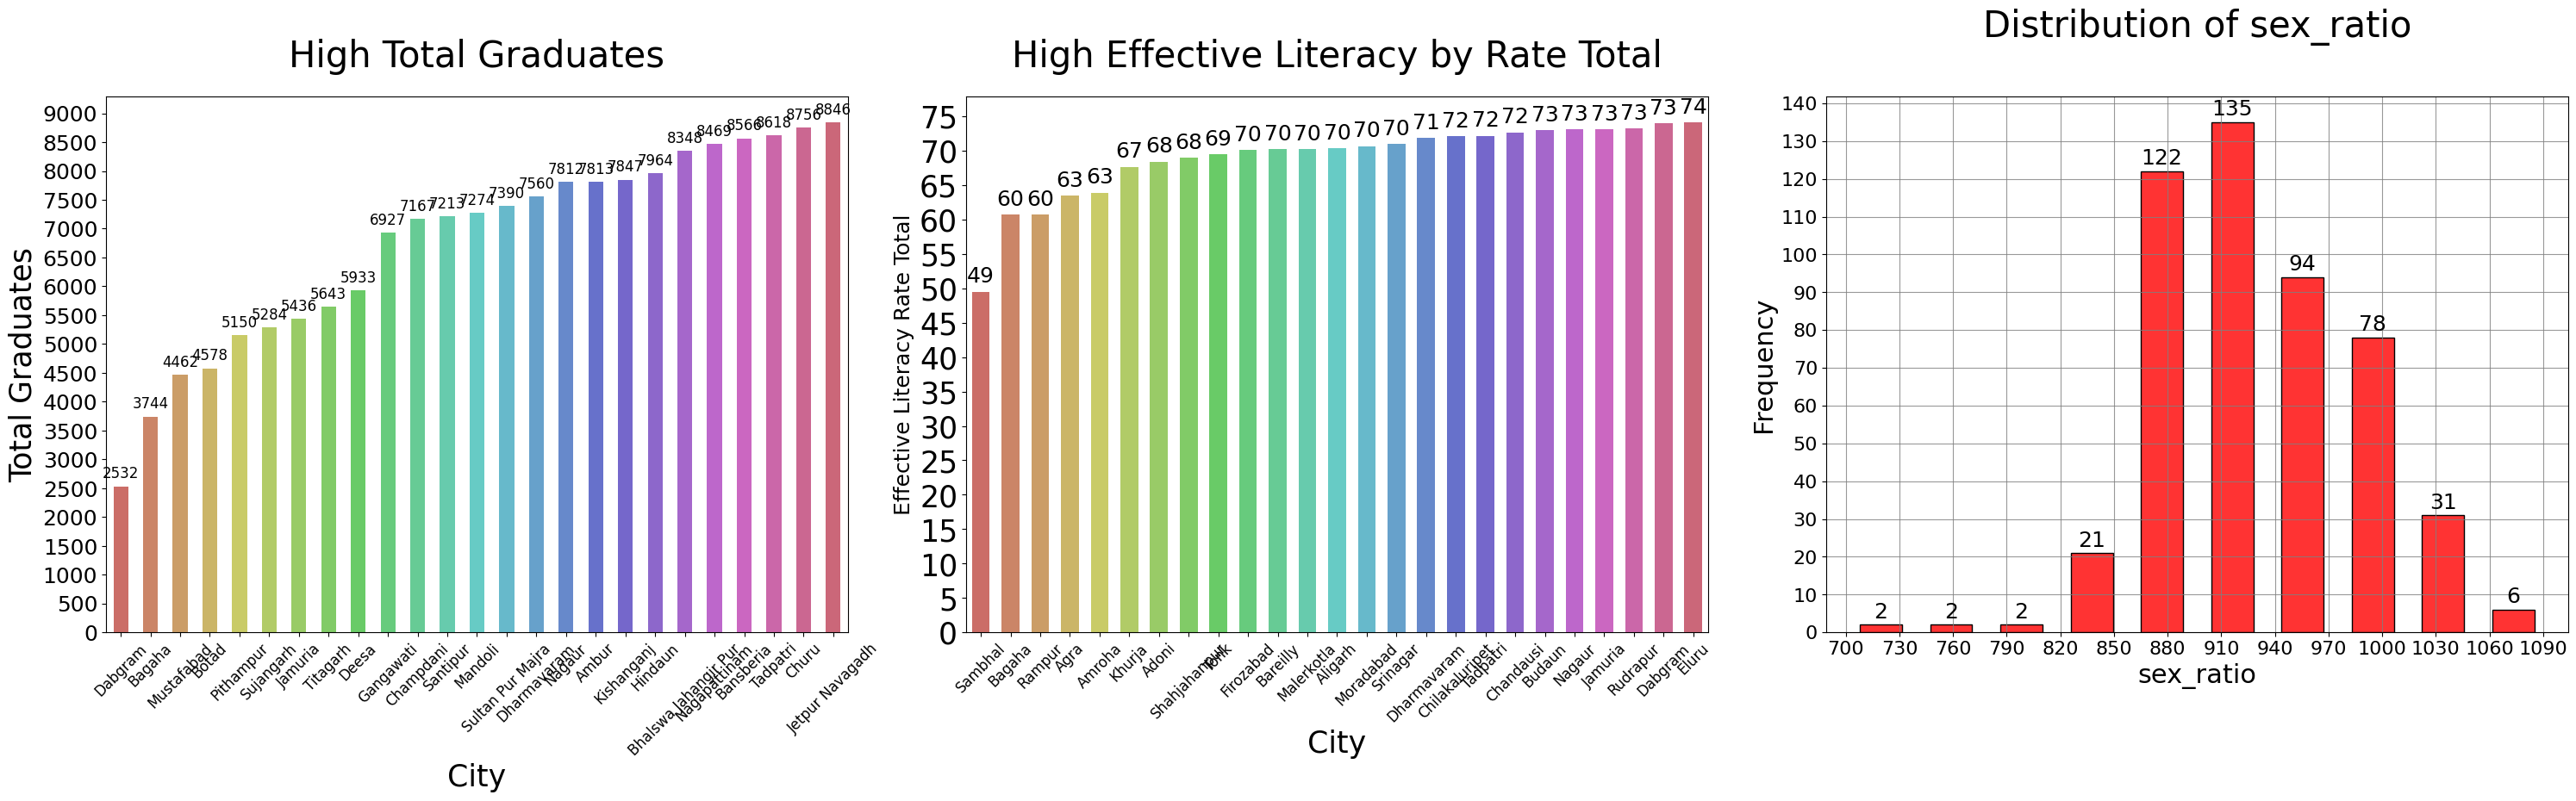

In [262]:
plt.figure(figsize=(30,24))
# subplot 1: High Total Graduates
plt.subplot(3,3,1)
top_cities = df.sort_values('total_graduates', ascending=True).head(25)

ax=sns.barplot(
    x='name_of_city',
    y='total_graduates',
    palette='hls',
    data=top_cities,width=0.5
)

plt.title('High Total Graduates', fontsize=30, pad=25)
plt.ylabel('Total Graduates', fontsize=25)
plt.xlabel('City', fontsize=25)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(range(0,9500,500),fontsize=18)
plt.tight_layout()
# إضافة الأرقام فوق الأعمدة
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=12, padding=4)

# subplot 2: High Effective Literacy by Rate Total    
plt.subplot(3,3,2)
top_cities = df.sort_values('effective_literacy_rate_total', ascending=True).head(25)

ax = sns.barplot(
    x='name_of_city',
    y='effective_literacy_rate_total',   
    palette='hls',
    data=top_cities,
    width=0.6
)

plt.xticks(rotation=45, fontsize=12)
plt.title('High Effective Literacy by Rate Total', fontsize=30, pad=25)
plt.yticks(range(0,80,5),fontsize=25)
plt.ylabel('Effective Literacy Rate Total', fontsize=18)
plt.xlabel('City', fontsize=25)
plt.tight_layout()
# إضافة الأرقام فوق الأعمدة
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=18, padding=4)

# subplot 3: Distribution of sex_ratio
plt.subplot(3,3,3)
ax=sns.histplot(df['sex_ratio'], bins=10, edgecolor='black', alpha=0.8,color='red',shrink=0.6)

plt.title("Distribution of sex_ratio", fontsize=30, pad=50)
plt.xlabel("sex_ratio", fontsize=22)
plt.ylabel("Frequency", fontsize=22)

plt.xticks(range(700,1095,30),fontsize=16)
plt.yticks(range(0,150,10),fontsize=16)

plt.grid(alpha=0.8,color='gray')

plt.tight_layout()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=18, padding=2)



## **Preprocessing**

#### **Drop Unneeded Columns**

In [263]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 493 entries, 0 to 492
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   name_of_city                    493 non-null    object 
 1   state_code                      493 non-null    int64  
 2   state_name                      493 non-null    object 
 3   dist_code                       493 non-null    int64  
 4   population_total                493 non-null    int64  
 5   population_male                 493 non-null    int64  
 6   population_female               493 non-null    int64  
 7   0-6_population_total            493 non-null    int64  
 8   0-6_population_male             493 non-null    int64  
 9   0-6_population_female           493 non-null    int64  
 10  literates_total                 493 non-null    int64  
 11  literates_male                  493 non-null    int64  
 12  literates_female                493 

In [264]:
df.drop(columns=['name_of_city','state_name','state_code','location','dist_code'],inplace=True )


# x and y

In [265]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 493 entries, 0 to 492
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   population_total                493 non-null    int64  
 1   population_male                 493 non-null    int64  
 2   population_female               493 non-null    int64  
 3   0-6_population_total            493 non-null    int64  
 4   0-6_population_male             493 non-null    int64  
 5   0-6_population_female           493 non-null    int64  
 6   literates_total                 493 non-null    int64  
 7   literates_male                  493 non-null    int64  
 8   literates_female                493 non-null    int64  
 9   sex_ratio                       493 non-null    int64  
 10  child_sex_ratio                 493 non-null    int64  
 11  effective_literacy_rate_total   493 non-null    float64
 12  effective_literacy_rate_male    493 

In [266]:
x=df.drop('population_total',axis=1)
y=df['population_total']

In [267]:
x

,population_male,population_female,0-6_population_total,0-6_population_male,0-6_population_female,literates_total,literates_male,literates_female,sex_ratio,child_sex_ratio,effective_literacy_rate_total,effective_literacy_rate_male,effective_literacy_rate_female,total_graduates,male_graduates,female_graduates
0,76840,68398,15870,8587,7283,103319,58347,44972,890,848,79.86,85.49,73.59,16287,8612,7675
1,58256,54037,11810,6186,5624,92433,49347,43086,928,909,91.99,94.77,89.00,8863,5269,3594
2,59232,58156,13103,6731,6372,83955,46295,37660,982,947,80.51,88.18,72.73,10565,6797,3768
3,91495,82493,23042,12063,10979,125985,71470,54515,902,910,83.46,89.98,76.23,19225,12189,7036
4,82743,83794,18406,9355,9051,101292,56203,45089,1013,968,68.38,76.58,60.33,11902,7871,4031
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488,111596,115937,20487,10495,9992,169461,89155,80306,1039,952,81.85,88.18,75.80,30656,19173,11483
489,310400,309716,55392,28434,26958,475247,258111,217136,998,948,84.16,91.54,76.79,109613,69507,40106
490,53241,52302,9754,5139,4615,90091,46752,43339,982,898,94.05,97.19,90.88,19363,10645,8718
491,115404,101224,22905,12556,10349,166419,92164,74255,877,824,85.91,89.61,81.71,29803,14349,15454


In [268]:
y

0      145238
1      112293
2      117388
3      173988
4      166537
        ...  
488    227533
489    620116
490    105543
491    216628
492    116714
Name: population_total, Length: 493, dtype: int64

# labelencoder

don't need

In [269]:
x

,population_male,population_female,0-6_population_total,0-6_population_male,0-6_population_female,literates_total,literates_male,literates_female,sex_ratio,child_sex_ratio,effective_literacy_rate_total,effective_literacy_rate_male,effective_literacy_rate_female,total_graduates,male_graduates,female_graduates
0,76840,68398,15870,8587,7283,103319,58347,44972,890,848,79.86,85.49,73.59,16287,8612,7675
1,58256,54037,11810,6186,5624,92433,49347,43086,928,909,91.99,94.77,89.00,8863,5269,3594
2,59232,58156,13103,6731,6372,83955,46295,37660,982,947,80.51,88.18,72.73,10565,6797,3768
3,91495,82493,23042,12063,10979,125985,71470,54515,902,910,83.46,89.98,76.23,19225,12189,7036
4,82743,83794,18406,9355,9051,101292,56203,45089,1013,968,68.38,76.58,60.33,11902,7871,4031
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488,111596,115937,20487,10495,9992,169461,89155,80306,1039,952,81.85,88.18,75.80,30656,19173,11483
489,310400,309716,55392,28434,26958,475247,258111,217136,998,948,84.16,91.54,76.79,109613,69507,40106
490,53241,52302,9754,5139,4615,90091,46752,43339,982,898,94.05,97.19,90.88,19363,10645,8718
491,115404,101224,22905,12556,10349,166419,92164,74255,877,824,85.91,89.61,81.71,29803,14349,15454


In [270]:
y

0      145238
1      112293
2      117388
3      173988
4      166537
        ...  
488    227533
489    620116
490    105543
491    216628
492    116714
Name: population_total, Length: 493, dtype: int64

# scaler

In [271]:
scaler=MinMaxScaler()
x=scaler.fit_transform(x)

In [272]:
x

array([[0.00398393, 0.00408531, 0.00775154, ..., 0.00619984, 0.00571778,
        0.00677642],
       [0.00120465, 0.00156429, 0.00437589, ..., 0.00285359, 0.00295116,
        0.0027369 ],
       [0.00135061, 0.00228737, 0.00545094, ..., 0.00362074, 0.00421571,
        0.00290913],
       ...,
       [0.00045464, 0.00125972, 0.00266644, ..., 0.0075863 , 0.00740025,
        0.00780882],
       [0.00975127, 0.00984779, 0.01360075, ..., 0.01229196, 0.01046562,
        0.01447636],
       [0.00127359, 0.00225946, 0.00376976, ..., 0.00494861, 0.00471226,
        0.00523129]], shape=(493, 16))

In [273]:
y = scaler.fit_transform(y.values.reshape(-1, 1))

In [274]:
y

array([[3.65168033e-03],
       [9.90191714e-04],
       [1.40179543e-03],
       [5.97427247e-03],
       [5.37233737e-03],
       [2.42076305e-02],
       [1.19119166e-01],
       [4.41942750e-01],
       [2.02666562e-02],
       [1.54935880e-02],
       [3.57512770e-02],
       [9.33722430e-04],
       [2.64258474e-02],
       [5.18047106e-03],
       [5.98849077e-03],
       [6.24101914e-02],
       [8.21638577e-02],
       [1.73910852e-02],
       [7.76997952e-03],
       [3.41885562e-04],
       [1.24383493e-02],
       [3.05449544e-02],
       [1.17454494e-03],
       [1.11645994e-03],
       [4.41708552e-02],
       [4.80190874e-04],
       [8.34295290e-02],
       [7.84422169e-03],
       [7.86167142e-03],
       [1.31118606e-02],
       [6.84175053e-04],
       [1.30116054e-02],
       [3.75213749e-02],
       [1.92835736e-03],
       [1.19886147e-04],
       [8.65453571e-02],
       [1.97654610e-02],
       [8.84119941e-04],
       [6.09771319e-03],
       [1.04827671e-03],


#  data split

In [275]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=50,test_size=0.3)

# LINEARREGRESSION,LASSO,RIDGE,SGDREGRESSOR

In [282]:
lr=LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [283]:
lr.score(x_train,y_train)

1.0

In [284]:
lr.score(x_test,y_test)

1.0

In [292]:
y_pred=lr.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

2.938942115033968e-17


In [293]:
y_pred=lr.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

2.5399999882097062e-17


In [294]:
lasso=Lasso(alpha=0,max_iter=1200,selection='cyclic')
lasso.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1365: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(


,alpha,0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1200
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [295]:
lasso.score(x_train,y_train)

0.9999853525070441

In [296]:
lasso.score(x_test,y_test)

0.9999328294804471

In [297]:
y_pred=lasso.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.0001911746047643505


In [298]:
y_pred=lasso.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.00018890224571979321


In [299]:
ridge=Ridge(alpha=0,max_iter=1000)
ridge.fit(x_train,y_train)

,alpha,0
,fit_intercept,True
,copy_X,True
,max_iter,1000
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [300]:
ridge.score(x_train,y_train)

1.0

In [301]:
ridge.score(x_test,y_test)

1.0

In [302]:
y_pred=ridge.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

3.260337350338584e-17


In [303]:
y_pred=ridge.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

3.187774157818022e-17


In [304]:
sgd=SGDRegressor(alpha=0,tol=0,epsilon=0)
sgd.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,loss,'squared_error'
,penalty,'l2'
,alpha,0
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0
,shuffle,True
,verbose,0
,epsilon,0
,random_state,None


In [305]:
sgd.score(x_train,y_train)

0.996936278698574

In [306]:
sgd.score(x_test,y_test)

0.9924292515394211

In [307]:
y_pred=sgd.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.0019060464991570523


In [308]:
y_pred=sgd.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.0016488995041153026


# SVR

In [309]:
svm=SVR(kernel='rbf',gamma='scale',C=10000,tol=0.001,degree=15,epsilon=0)
svm.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,kernel,'rbf'
,degree,15
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,10000
,epsilon,0
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [310]:
svm.score(x_train,y_train)

0.9999968397286402

In [311]:
svm.score(x_test,y_test)

0.998293200832704

In [312]:
y_pred=svm.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.0001333661356276473


In [313]:
y_pred=svm.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.00038700600735146087


# tree

In [314]:
tree=DecisionTreeRegressor(splitter='best',max_depth=100,criterion='absolute_error',min_samples_split=2,min_samples_leaf=2)
tree.fit(x_train,y_train)

,criterion,'absolute_error'
,splitter,'best'
,max_depth,100
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [315]:
tree.score(x_train,y_train)

0.9858298452214611

In [316]:
tree.score(x_test,y_test)

0.9762928405864093

In [317]:
y_pred=tree.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.001728452283061468


In [318]:
y_pred=tree.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.0017578670922585586


# neghibour

In [319]:
neghibour=KNeighborsRegressor(n_neighbors=1,algorithm='auto',p=2,n_jobs=100)
neghibour.fit(x_train,y_train)

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,100


In [320]:
neghibour.score(x_train,y_train)

1.0

In [321]:
neghibour.score(x_test,y_test)

0.9455872950615911

In [322]:
y_pred=neghibour.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.0


In [323]:
y_pred=neghibour.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.006570309104010724


# catboost

In [324]:
cat=CatBoostRegressor()
cat.fit(x_train,y_train)

Learning rate set to 0.034606
0:	learn: 0.0923133	total: 17.7ms	remaining: 17.6s
1:	learn: 0.0910587	total: 22.2ms	remaining: 11.1s
2:	learn: 0.0897083	total: 28.8ms	remaining: 9.57s
3:	learn: 0.0879724	total: 35.1ms	remaining: 8.74s
4:	learn: 0.0862880	total: 45.1ms	remaining: 8.98s
5:	learn: 0.0846346	total: 52.1ms	remaining: 8.63s
6:	learn: 0.0829404	total: 62.9ms	remaining: 8.91s
7:	learn: 0.0816321	total: 71.2ms	remaining: 8.83s
8:	learn: 0.0802882	total: 79.8ms	remaining: 8.78s
9:	learn: 0.0786845	total: 84.6ms	remaining: 8.37s
10:	learn: 0.0773270	total: 90.3ms	remaining: 8.11s
11:	learn: 0.0761595	total: 94.3ms	remaining: 7.76s
12:	learn: 0.0747035	total: 98ms	remaining: 7.44s
13:	learn: 0.0732968	total: 101ms	remaining: 7.14s
14:	learn: 0.0718981	total: 106ms	remaining: 6.97s
15:	learn: 0.0708393	total: 111ms	remaining: 6.81s
16:	learn: 0.0696824	total: 114ms	remaining: 6.56s
17:	learn: 0.0684415	total: 116ms	remaining: 6.35s
18:	learn: 0.0670527	total: 120ms	remaining: 6.21s


In [325]:
cat.score(x_train,y_train)

np.float64(0.9999859419233447)

In [326]:
cat.score(x_test,y_test)

np.float64(0.9889729691961759)

In [327]:
y_pred=cat.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.0002748808076839859


In [328]:
y_pred=cat.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.0017771616160319871


# lightgmb

In [329]:
light=LGBMRegressor(num_leaves=50,max_depth=0,n_estimators=1000)
light.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000172 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1789
[LightGBM] [Info] Number of data points in the train set: 345, number of used features: 16
[LightGBM] [Info] Start training from score 0.030850
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

,boosting_type,'gbdt'
,num_leaves,50
,max_depth,0
,learning_rate,0.1
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [330]:
light.score(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


0.9971950347205196

In [331]:
light.score(x_test,y_test)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


-0.7544440977897211

In [332]:
y_pred=light.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.0016928738012782648


c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [333]:
y_pred=light.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.02654694608670406


c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


# xgboost

In [334]:
xgb=XGBRegressor()
xgb.fit(x_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [335]:
xgb.score(x_train,y_train)

0.9999873308528914

In [336]:
xgb.score(x_test,y_test)

0.9662357676123737

In [337]:
y_pred=xgb.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.00022776885732727392


In [338]:
y_pred=xgb.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

0.0017908222812344462


# Deep learning

In [339]:
x.shape

(493, 16)

In [346]:
model=Sequential([
    Dense(64,activation='relu',input_dim=16),
    Dense(32,activation='relu'),
    Dense(16,activation='relu'),
    Dense(8,activation='relu'),
    Dense(4,activation='relu'),
    Dense(2,activation='relu'),
    Dense(1,activation='linear')])
model.compile(optimizer=Adam(learning_rate=0.001),loss='mean_absolute_error',metrics=['mae'])

In [347]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,881 (15.16 KB)

 Trainable params: 3,881 (15.16 KB)

 Non-trainable params: 0 (0.00 B)

In [348]:
earlystop=EarlyStopping(monitor='val_loss',patience=15,restore_best_weights=True)
reducelr=ReduceLROnPlateau(monitor='val_loss',patience=12,factor=0.1)
logger=CSVLogger('file.csv')
weight=ModelCheckpoint('weight.h5')

In [349]:
model.fit(x_train, y_train, epochs=80,validation_split=0.3,callbacks=[earlystop,reducelr,logger,weight])

Epoch 1/80
1/8 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - loss: 0.0488 - mae: 0.0488

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0387 - mae: 0.0387 - val_loss: 0.0234 - val_mae: 0.0234 - learning_rate: 0.0010
Epoch 2/80
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0231 - mae: 0.0231

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0302 - mae: 0.0302 - val_loss: 0.0233 - val_mae: 0.0233 - learning_rate: 0.0010
Epoch 3/80
6/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0203 - mae: 0.0203

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0303 - mae: 0.0303 - val_loss: 0.0233 - val_mae: 0.0233 - learning_rate: 0.0010
Epoch 4/80
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0392 - mae: 0.0392

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0302 - mae: 0.0302 - val_loss: 0.0235 - val_mae: 0.0235 - learning_rate: 0.0010
Epoch 5/80
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0087 - mae: 0.0087

...

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0301 - mae: 0.0301 - val_loss: 0.0235 - val_mae: 0.0235 - learning_rate: 0.0010
Epoch 14/80
1/8 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - loss: 0.0448 - mae: 0.0448

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0301 - mae: 0.0301 - val_loss: 0.0234 - val_mae: 0.0234 - learning_rate: 0.0010
Epoch 15/80
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0803 - mae: 0.0803

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0301 - mae: 0.0301 - val_loss: 0.0234 - val_mae: 0.0234 - learning_rate: 1.0000e-04
Epoch 16/80
1/8 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - loss: 0.0117 - mae: 0.0117

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0301 - mae: 0.0301 - val_loss: 0.0234 - val_mae: 0.0234 - learning_rate: 1.0000e-04
Epoch 17/80
1/8 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - loss: 0.0174 - mae: 0.0174

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0301 - mae: 0.0301 - val_loss: 0.0235 - val_mae: 0.0235 - learning_rate: 1.0000e-04


In [350]:
model.evaluate(x_train,y_train)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0281 - mae: 0.0281 


[0.02813677303493023, 0.02813677303493023]

In [351]:
model.evaluate(x_test,y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0195 - mae: 0.0195 


[0.0194530189037323, 0.0194530189037323]